In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Tuple, Optional, Union

import gcsfs
import os
import sys
import json
from pprint import pprint

#fs = gcsfs.GCSFileSystem()
#fs.ls("gs://leap-persistent/sammyagrawal/") # List files in the bucket where the E3SM-MMF dataset is stored

In [3]:
sys.path.append(os.path.abspath(os.path.join('../diffusionsim')))
import torch
import torch.nn as nn
import xbatcher
import torch.nn.functional as F

import diffusers
#import physicsnemo as modulus
import diffusionsim as diff
import diffusionsim.training_utils as tru
from diffusionsim.climsim_utils import imagify
from diffusionsim import mydatasets as data
from diffusionsim import models as models
#import diffusionsim.evaluations as evals

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [6]:
diffusers.__file__

'/srv/conda/envs/notebook/lib/python3.12/site-packages/diffusers/__init__.py'

In [7]:
torch.manual_seed(0)
np.random.seed(0)

## Data

In [6]:
source = "local-vzarr" if True else "gcsfs"

dconfig = tru.my_dconfig(source, "v1", in_notebook=True, shuffle_indices=False, 
                        dataset_type="climsim", batch_size=1, use_tendencies=False)
dconfig.train_test_split = [1.0]
dconfig.phases = ["train"]
pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           num_epochs=10,
           phases=['train'],
           train_test_split=[1.0],
           dataloader_params=DataLoaderParams(batch_size=1,
                                              shuffle=True,
                                              num_workers=0,
                                              prefetch_factor=None,
                                              persistent_workers=False,
                                              multiprocessing_context=None,
                                              pin_memory=False),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           chunksize={},
           shuffle_indices=False,
           distributed_training=False,
           checkpoint_best_epoch=True,
           checkpoint

In [7]:
dataloaders, [indices] = data.load_dataloaders(dconfig, log=False, indices=None)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [8]:
dl = dataloaders[0]
ds = dl.dataset
dutils = ds.dutils

In [9]:
x, y = next(iter(dl))
## imagify(x, ds.dutils, 'x', 1).shape

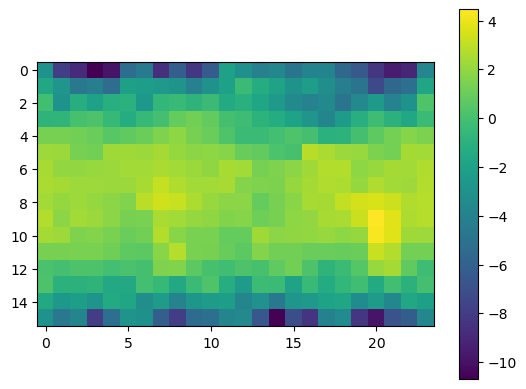

In [10]:
plt.imshow(imagify(y, ds.dutils, 'y', 2)[0, 59].cpu().detach().numpy())
plt.colorbar()

In [11]:
def plot_profile(data, var_index=None, ax=None, title='', **kwargs):
    data = np.asarray(data)
    assert data.ndim < 4, "no more than 3d"
    if data.ndim == 3:
        assert var_index is not None, "need to specify variable"
        data = data[:, var_index, :]
    elif(data.ndim == 2 and data.shape[0] == 10):
        data = data[var_index]
    levels = np.arange(data.shape[-1])
    if ax is None:
        fig, ax = plt.subplots()
    if data.ndim == 1:
        ax.plot(data, levels, **kwargs)
    else:
        for profile in data: 
            ax.plot(profile, levels, **kwargs) 
    ax.invert_yaxis()
    ax.set_ylabel("Level index (0 = top)")
    ax.set_title(title)
    if var_index is not None: 
        ax.set_xlabel(ds.target_vars[var_index])

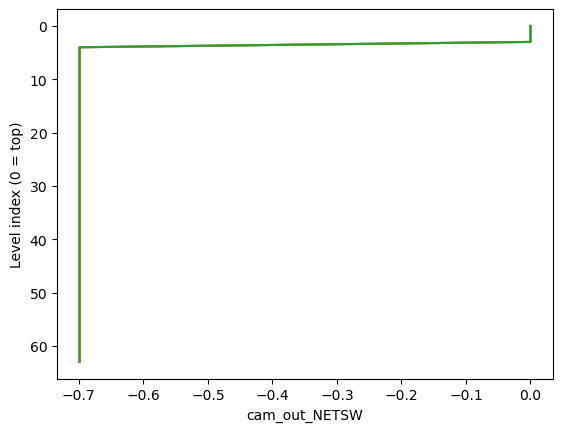

In [13]:
plot_profile(imagify(y, ds.dutils, 'y', 1)[0:3], 2)

# How Diffusion Works

### Sampling $x_t$ from markov chain
[DDPM Paper](https://arxiv.org/pdf/2006.11239)
Given a **fixed** noise schedule $\{\beta_1, ..., \beta_T\}$, we can define $\alpha_t:= 1- \beta_t$ and $\bar{\alpha_t} = \prod_{s=1}^t \alpha_s$

Giving rules for products of gaussians, we can conveniently sample from any arbitrary node in the Markov Chain as long as we condition on $x_0$. q(xt|x0)=N(√¯αt⋅x0,(1−¯αt)I)q(x_t|x_0) = \mathcal N(\sqrt{\bar{\alpha_t}} \cdot x_0, (1-\bar{\alpha_t}) I)

Given a sample $\epsilon$ drawn from a standard gaussian, we leverage this to reparameterize xt(x0,ϵ)=√¯αt⋅x0+√1−¯αt⋅ϵx_t(x_0, \epsilon) = \sqrt{\bar{\alpha_t}} \cdot x_0 + \sqrt{1-\bar{\alpha_t}} \cdot \epsilon


The loss, which can also be interpreted as training a noise-conditional score based model, is (14) from the paper: $$L_{simple} := \mathbb{E} [||\epsilon - \epsilon_\theta(x_t(x_0, \epsilon, t), t)||^2]$$

In [14]:
IMAGE_DIM = 1
input_sample = imagify(y, ds.dutils, 'y', IMAGE_DIM)
input_sample.shape

torch.Size([49152, 10, 64])

In [15]:
train_steps = 100

In [16]:
scheduler_type = "ddpm" 
scheduler_params = tru.SchedulerParams(num_train_timesteps=train_steps)
scheduler_params

SchedulerParams(num_train_timesteps=100, beta_schedule='linear', clip_sample=False, clip_sample_range=4.0, beta_end=0.02)

In [17]:
scheduler_class = diffusers.DDPMScheduler if scheduler_type=="ddpm" else diffusers.DDIMScheduler
noise_scheduler = scheduler_class(**asdict(scheduler_params))

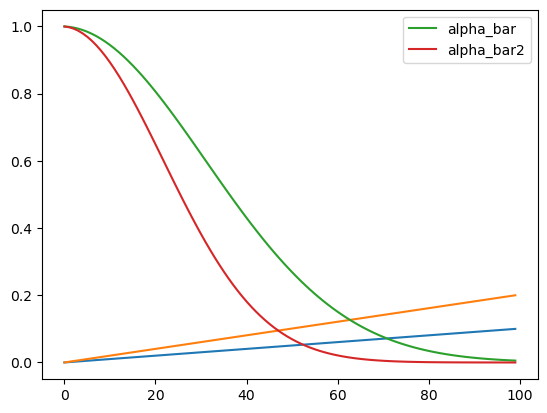

In [18]:

scheduler = diffusers.DDPMScheduler(
    num_train_timesteps=100,
    beta_start=0.0001,
    beta_end=0.1,  # Changed from 0.01 to 0.2
    beta_schedule="linear",
)
scheduler2 = diffusers.DDPMScheduler(
    num_train_timesteps=100,
    beta_start=0.0001,
    beta_end=0.2,  # Changed from 0.01 to 0.2
    beta_schedule="linear",
)
plt.plot(scheduler.betas) # how much noise
plt.plot(scheduler2.betas)
plt.plot(scheduler.alphas_cumprod, label='alpha_bar') # how much signal vs noise
plt.plot(scheduler2.alphas_cumprod, label='alpha_bar2')
plt.legend()
plt.show()

In [ ]:
print(noise_scheduler.config.num_train_timesteps)
print(noise_scheduler.timesteps)
noise_scheduler.set_timesteps(10)
print(noise_scheduler.timesteps)
noise_scheduler.set_timesteps(100)

In [ ]:
def get_alpha_t_manual(t, scheduler=noise_scheduler):
    a = 1
    for s in range(t+1):
        a = a * (1-scheduler.betas[s])
    return(a)
print(get_alpha_t_manual(5) - noise_scheduler.alphas_cumprod[5])
noise_scheduler.alphas_cumprod[:6]

In [ ]:
fig, axes = plt.subplots(1, 2, sharex=True)
axes[1].plot(noise_scheduler.alphas_cumprod, label='alpha_bar')
axes[0].plot(noise_scheduler.betas, label='betas', color='orange')
plt.legend()
plt.show()

In [ ]:
def sample_xt(x0, t):
    eps = torch.randn(x0.shape) # BS x C x H x W
    xt = noise_scheduler.add_noise(x0, eps, torch.LongTensor(t)) # noisy image
    return(xt, eps)

In [ ]:
t = 50
x50, eps = sample_xt(input_sample, [t])

In [ ]:
at = noise_scheduler.alphas_cumprod[t]
x50_manual = torch.sqrt(at) * input_sample + torch.sqrt(1-at)*eps

In [ ]:
loss_fn = torch.nn.MSELoss()

In [ ]:
(x50_manual == x50).all() # the same! 

Loss called to match model prediction to actual noise used to generate noisy latent. 

training_loss = loss_fn(model(x_t, t).sample, epsilon_noise_sample)

In [ ]:
eps.shape, input_sample.shape

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
var_index = 0
if IMAGE_DIM == 1:
    
    plot_profile(input_sample[0, var_index], ax=axes[0], title="Original", )
    
    plot_profile(x50[0, var_index], ax=axes[1], title="Noisy", var_index=0)
    
    plot_profile(eps[0, var_index], ax=axes[2], title="Noise", var_index=0)
    
    plt.tight_layout()
    plt.show()
elif IMAGE_DIM == 2:
    im0 = axes[0].imshow(input_sample.permute(0, 2, 3, 1).cpu().numpy()[0, :, :, 59], 'viridis')
    axes[0].title.set_text("x0 original sample")
    axes[0].set_axis_off()
    
    im1 = axes[1].imshow(x50.permute(0, 2, 3, 1).cpu().numpy()[0, :, :, 59], 'viridis')
    axes[1].set_axis_off()
    axes[1].title.set_text("x50 noisy sample")
    
    im2 = axes[2].imshow(eps[0, 59, :, :], 'viridis')
    axes[2].set_axis_off()
    axes[2].title.set_text("Noise Level eps")
    
    fig.colorbar(im0, ax=axes[0], orientation='vertical')
    fig.colorbar(im1, ax=axes[1], orientation='vertical')
    fig.colorbar(im2, ax=axes[2], orientation='vertical')
    plt.show()

In [ ]:
x100, eps = sample_xt(input_sample, [99])

In [ ]:
if IMAGE_DIM == 1:
    plot_profile(x100[26, var_index], color='orange')
else:
    plt.imshow(x100[0, 59])

### How much Noise Destroys Sample? 

$$ \mathbb{E}[(X+\epsilon)^T (X+\epsilon)] = \mathbb{E}[(X^T X +\epsilon^T \epsilon)]$$
=VΛV−1+Vσ2IV−1=V(Λ+σ2I)V−1 = V \Lambda V^{-1} + V \sigma^2 I V^{-1} = V (\Lambda + \sigma^2 I) V^{-1}

In [ ]:
print(input_sample.shape)

X = input_sample.reshape(128, -1)
X.shape

In [ ]:
plt.hist(X.flatten())

In [ ]:
M = torch.matmul(X, torch.transpose(X, 0, 1)).numpy()
print(f"M symmetric: {np.isclose(M, M.T).all()}")
M.shape

In [ ]:
eig, Q = np.linalg.eigh(M)

In [ ]:
Mhat = np.dot(np.dot(Q, np.diag(eig)), Q.T)

plt.imshow(Mhat - M)
plt.colorbar()

In [ ]:
eig[-5:]

These eigenvalues seem really high...

## How Reverse Diffusion with trained model works

Given $\epsilon$, we can obtain the distribution for a reverse diffusion step. Recall that pθ(xt−1|xt):=N(xt−1;μθ(xt,t),Σθ=σ2tI)p_\theta(x_{t-1} | x_t) := \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta=\sigma_t^2 I)
where $\sigma_t^2=\beta_t$ is a common choice. 


xt−1=1αt(xt−βt√1−αtϵθ(xt,t))+σtzz∼N(0,I)x_{t-1} =\dfrac{1}{\alpha_t}\left(x_t - \dfrac{\beta_t}{\sqrt{1-\alpha_t}} \epsilon_\theta(x_t, t)\right) + \sigma_t z \,\,\,\,\,\, z \sim \mathcal N(0, I)

More simply, since $x_t = \sqrt{1 - \beta_t} x_{t-1} + \sqrt{\beta_t} \sigma_t$, then $x_{t-1} = \dfrac{1}{\alpha_t}(x_t - \sqrt{\beta_t} \epsilon_\theta)$

In [ ]:
noise_scheduler.timesteps

In [ ]:
x50.shape, eps.shape

In [ ]:
gen = torch.Generator()

In [ ]:
x49 = noise_scheduler.step(eps, timestep=50, sample=x50, generator=gen).prev_sample
x49.shape

In [ ]:
step = noise_scheduler.step(eps, timestep=50, sample=x50, generator=gen)
x49b, x0_hat = step.prev_sample, step.pred_original_sample


In [ ]:
sigma_diff = (x49 - x49b).numpy() / np.sqrt(noise_scheduler.betas[50])
print(sigma_diff.shape)
if IMAGE_DIM == 1:
    plot_profile(sigma_diff[0,0])
else:
    plt.imshow(sigma_diff[0,59,:,:]/2)
    plt.colorbar()

In [ ]:
def manual_inference_step(epsilon, t, xt, scheduler):
    # x t-1
    bt = noise_scheduler.betas[t]
    x = xt - np.sqrt(bt) * epsilon
    x = x / np.sqrt(1 - bt)
    return(x)

In [ ]:
def run_pipeline(model, scheduler):
    # get x t-1 given x_t
    input =  torch.randn(input_sample.shape)
    for t in scheduler.timesteps:
        with torch.no_grad():
            noisy_residual = model(input, t).sample
        previous_noisy_sample = scheduler.step(noisy_residual, t, input).prev_sample
        input = previous_noisy_sample


In [ ]:
x49_manual = manual_inference_step(eps, 50, x50, noise_scheduler)

In [ ]:
x49_manual.shape

# U Net Models

Ok so we have our noisy dataset and our well defined task. Let's explore the model!

- U Net at its core is a convolution based encoder decoder architecture that progressively reduces height/width dimensionality but adds channels with "down blocks" and rescales with "upblocks". Residual connections as well
- Timestep is fed into noise-conditional model via a time embedding. "temb" is a parameter in all the downsample blocks


Resources: 
- [Time Embeddings and conditioning](https://varun-ml.github.io/posts/diffusion-models/denoising-diffusion-models-2/)

In [8]:
import inspect
def pass_config(func, data_class):
    # only pass model config params that function takes in
    accepted_params = inspect.signature(func).parameters
    filtered_kwargs = {k: v for k, v in asdict(data_class).items() if k in accepted_params}
    return func(**filtered_kwargs)

## 1D Diffusion - Huggingface Model

[Source code](https://github.com/huggingface/diffusers/blob/v0.34.0/src/diffusers/models/unets/unet_1d.py#L41)

[Projection Embedding src](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/embeddings.py#L1321)

In [203]:
from diffusionsim.models.conv_blocks import *
from diffusionsim.models.unets import *


In [204]:
class DownBlock1D(nn.Module):
    def __init__(
        self, 
        out_channels: int, 
        in_channels: int, 
        mid_channels: Optional[int] = None, 
        use_down=False,
        use_up=False, 
        concat_temb=False,
        attention=False,
        temb_channels=None,
    ):
        super().__init__()
        mid_channels = out_channels if mid_channels is None else mid_channels
        self.down = Downsample1d("cubic") if use_down else None
        self.up = Upsample1d(kernel="cubic") if use_up else None
        
        self.resnets = nn.ModuleList([
            ResConvBlock(in_channels, mid_channels, mid_channels),
            ResConvBlock(mid_channels, mid_channels, mid_channels),
            ResConvBlock(mid_channels, mid_channels, out_channels),
        ])
        self.attentions = None
        if attention:
            self.attentions = nn.ModuleList([
                SelfAttention1d(mid_channels, mid_channels // 32),
                SelfAttention1d(mid_channels, mid_channels // 32),
                SelfAttention1d(out_channels, out_channels // 32),
            ])
        print("temb_channels", temb_channels, in_channels)
        self.time_embedding = UNetCondEmbedding(in_channels, temb_channels, emb_method="add", projection_method="linear") if concat_temb else None

    def forward(
            self, 
            hidden_states: torch.Tensor, 
            temb: Optional[torch.Tensor] = None
        ) -> torch.Tensor:
        
        hidden_states = self.down(hidden_states) if self.down is not None else hidden_states
        hidden_states = self.time_embedding(hidden_states, temb) if self.time_embedding is not None and temb is not None else hidden_states
   
        for i, resnet in enumerate(self.resnets):
            hidden_states = resnet(hidden_states)
            if self.attentions is not None:
                hidden_states = self.attentions[i](hidden_states)
        
        hidden_states = self.up(hidden_states) if self.up is not None else hidden_states

        return hidden_states, (hidden_states,)

In [206]:
def get_down_block(
    down_block_type: str,
    num_layers: int,
    in_channels: int,
    out_channels: int,
    temb_channels: int,
    add_downsample: bool,
    concat_temb: bool = True,
) -> Union[DownResnetBlock1D, DownBlock1D, UNetBlock]:
    if down_block_type == "DownResnetBlock1D":
        return DownResnetBlock1D(
            in_channels=in_channels,
            num_layers=num_layers,
            out_channels=out_channels,
            temb_channels=temb_channels,
            add_downsample=add_downsample,
        )
    elif down_block_type == "UNetBlock":
        raise NotImplementedError("UNetBlock for NV is not implemented")
    assert down_block_type in ["DownBlock1D", "AttnDownBlock1D"], f"{down_block_type} does not exist."
    attn = bool("attn" in down_block_type.lower())
    return DownBlock1D(
        out_channels=out_channels,
        in_channels=in_channels,
        use_down=not attn,
        use_up=attn,
        concat_temb=concat_temb,
        attention=attn,
        temb_channels=temb_channels,
    )

In [228]:
class UpBlock1D(nn.Module):
    def __init__(
            self, 
            in_channels: int, 
            out_channels: int, 
            mid_channels: Optional[int] = None, 
            use_up=True,
            attention=False
        ):
        super().__init__()
        mid_channels = in_channels if mid_channels is None else mid_channels

        self.resnets = nn.ModuleList([
            ResConvBlock(2 * in_channels, mid_channels, mid_channels),
            ResConvBlock(mid_channels, mid_channels, mid_channels),
            ResConvBlock(mid_channels, mid_channels, out_channels),
        ])
        self.attentions = None
        if attention:
            self.attentions = nn.ModuleList([
                SelfAttention1d(mid_channels, mid_channels // 32),
                SelfAttention1d(mid_channels, mid_channels // 32),
                SelfAttention1d(out_channels, out_channels // 32),
            ])
        
        self.up = Upsample1d(kernel="cubic") if use_up else None

    def forward(
        self,
        hidden_states: torch.Tensor,
        res_hidden_states_tuple: Tuple[torch.Tensor, ...],
        temb: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        res_hidden_states = res_hidden_states_tuple[-1]
        hidden_states = torch.cat([hidden_states, res_hidden_states], dim=1)

        for i, resnet in enumerate(self.resnets):
            hidden_states = resnet(hidden_states)
            if self.attentions is not None:
                hidden_states = self.attentions[i](hidden_states)

        hidden_states = self.up(hidden_states) if self.up else hidden_states

        return hidden_states

In [237]:
def get_up_block(
    up_block_type: str, num_layers: int, in_channels: int, out_channels: int, temb_channels: int, add_upsample: bool
) -> Union[UpResnetBlock1D, UpBlock1D, UNetBlock]:
    if up_block_type == "UpResnetBlock1D":
        return UpResnetBlock1D(
            in_channels=in_channels,
            num_layers=num_layers,
            out_channels=out_channels,
            temb_channels=temb_channels,
            add_upsample=add_upsample,
        )
    elif up_block_type == "UNetBlock":
        raise NotImplementedError("UNetBlock for NV is not implemented")
    assert up_block_type in ["UpBlock1D", "AttnUpBlock1D"], f"{up_block_type} does not exist."
    attn = bool("attn" in up_block_type.lower())

    return UpBlock1D(
        in_channels=in_channels, out_channels=out_channels, 
        use_up=not attn, attention=attn
    )

In [238]:
class DiffusersUNet1D(diffusers.models.ModelMixin, diffusers.configuration_utils.ConfigMixin):
    r"""
    A 1D UNet model that takes a noisy sample and a timestep and returns a sample shaped output.
    Inspired by https://github.com/leap-stc/ClimSim/blob/main/online_testing/baseline_models/Unet_v5/training/climsim_unet.py
    This model inherits from [`ModelMixin`]. Check the superclass documentation for it's generic methods implemented
    for all models (such as downloading or saving).

    Parameters:
        in_channels (`int`, *optional*, defaults to 2): Number of channels in the input sample.
        out_channels (`int`, *optional*, defaults to 2): Number of channels in the output.
        extra_in_channels (`int`, *optional*, defaults to 0):
            Number of additional channels to be added to the input of the first down block. Useful for cases where the
            input data has more channels than what the model was initially designed for.
        time_embedding_type (`str`, *optional*, defaults to `"fourier"`): Type of time embedding to use.
        freq_shift (`float`, *optional*, defaults to 0.0): Frequency shift for Fourier time embedding.
        flip_sin_to_cos (`bool`, *optional*, defaults to `False`):
            Whether to flip sin to cos for Fourier time embedding.
        down_block_types (`Tuple[str]`, *optional*, defaults to `("DownBlock1DNoSkip", "DownBlock1D", "AttnDownBlock1D")`):
            Tuple of downsample block types.
        up_block_types (`Tuple[str]`, *optional*, defaults to `("AttnUpBlock1D", "UpBlock1D", "UpBlock1DNoSkip")`):
            Tuple of upsample block types.
        block_out_channels (`Tuple[int]`, *optional*, defaults to `(32, 32, 64)`):
            Tuple of block output channels.
        mid_block_type (`str`, *optional*, defaults to `"UNetMidBlock1D"`): Block type for middle of UNet.
        out_block_type (`str`, *optional*, defaults to `None`): Optional output processing block of UNet.
        act_fn (`str`, *optional*, defaults to `None`): Optional activation function in UNet blocks.
        norm_num_groups (`int`, *optional*, defaults to 8): The number of groups for normalization.
        layers_per_block (`int`, *optional*, defaults to 1): The number of conv blocks per resolution.
        downsample_each_block (`int`, *optional*, defaults to `False`):
            Experimental feature for using a UNet without upsampling.
    """

    _skip_layerwise_casting_patterns = ["norm"]

    @diffusers.configuration_utils.register_to_config
    def __init__(
        self,
        in_channels: int = 2,
        out_channels: int = 2,
        extra_in_channels: int = 0,
        time_embedding_type: str = "fourier",
        time_embedding_dim: int = 0,
        flip_sin_to_cos: bool = True,
        use_timestep_embedding: bool = False,
        freq_shift: float = 0.0,
        down_block_types: Tuple[str] = ("DownBlock1DNoSkip", "DownBlock1D", "AttnDownBlock1D"),
        up_block_types: Tuple[str] = ("AttnUpBlock1D", "UpBlock1D", "UpBlock1DNoSkip"),
        mid_block_type: Tuple[str] = "UNetMidBlock1D",
        out_block_type: str = None,
        block_out_channels: Tuple[int] = (32, 32, 64),
        act_fn: str = None,
        norm_num_groups: int = 8,
        layers_per_block: int = 1,
        downsample_each_block: bool = False,
        output_scale_type: str = "scale-only",
    ):
        super().__init__()

        # time
        if time_embedding_type == "fourier":
            time_embed_dim = time_embedding_dim or block_out_channels[0] * 2
            if time_embed_dim % 2 != 0:
                raise ValueError(f"`time_embed_dim` should be divisible by 2, but is {time_embed_dim}.")
            self.time_proj = diffusers.models.embeddings.GaussianFourierProjection(
                embedding_size=time_embed_dim // 2, set_W_to_weight=False, log=False, flip_sin_to_cos=flip_sin_to_cos
            )
        elif time_embedding_type == "positional":
            time_embed_dim = time_embedding_dim or block_out_channels[0]
            self.time_proj = diffusers.models.embeddings.Timesteps(
                time_embed_dim, flip_sin_to_cos=flip_sin_to_cos, downscale_freq_shift=freq_shift
            )
        else:
            raise ValueError(
                f"{time_embedding_type} does not exist. Please make sure to use one of `fourier` or `positional`."
            )

        if use_timestep_embedding:
            self.time_mlp = diffusers.models.embeddings.TimestepEmbedding(
                in_channels=time_embed_dim,
                time_embed_dim=block_out_channels[0] * 4,
                act_fn=act_fn if isinstance(act_fn, str) else "silu",
                out_dim=time_embedding_dim,
            )

        self.down_blocks = nn.ModuleList([])
        self.mid_block = None
        self.up_blocks = nn.ModuleList([])
        self.out_block = None

        # down
        output_channel = in_channels
        for i, down_block_type in enumerate(down_block_types):
            input_channel = output_channel
            output_channel = block_out_channels[i]

            if i == 0:
                input_channel += extra_in_channels

            is_final_block = i == len(block_out_channels) - 1

            down_block = get_down_block(
                down_block_type,
                num_layers=layers_per_block,
                in_channels=input_channel,
                out_channels=output_channel,
                temb_channels=time_embedding_dim,
                add_downsample=not is_final_block or downsample_each_block,
            )
            self.down_blocks.append(down_block)

        # mid
        self.mid_block = get_mid_block(
            mid_block_type,
            in_channels=block_out_channels[-1],
            mid_channels=block_out_channels[-1],
            out_channels=block_out_channels[-1],
            temb_channels=time_embedding_dim,
            num_layers=layers_per_block,
            add_downsample=downsample_each_block,
        )

        # up
        reversed_block_out_channels = list(reversed(block_out_channels))
        output_channel = reversed_block_out_channels[0]
        if out_block_type is None:
            final_upsample_channels = out_channels
        else:
            final_upsample_channels = block_out_channels[0]

        for i, up_block_type in enumerate(up_block_types):
            prev_output_channel = output_channel
            output_channel = (
                reversed_block_out_channels[i + 1] if i < len(up_block_types) - 1 else final_upsample_channels
            )

            is_final_block = i == len(block_out_channels) - 1

            up_block = get_up_block(
                up_block_type,
                num_layers=layers_per_block,
                in_channels=prev_output_channel,
                out_channels=output_channel,
                temb_channels=time_embedding_dim,
                add_upsample=not is_final_block,
            )
            self.up_blocks.append(up_block)
            prev_output_channel = output_channel

        # out
        num_groups_out = norm_num_groups if norm_num_groups is not None else min(block_out_channels[0] // 4, 32)
        self.out_block = get_out_block( # defined in conv_blocks.py
            out_block_type=out_block_type,
            num_groups_out=num_groups_out,
            embed_dim=block_out_channels[0],
            out_channels=out_channels,
            act_fn=act_fn,
            fc_dim=block_out_channels[-1] // 4,
        )
        if output_scale_type == 'affine' or "bias" in output_scale_type:
            self.scale_output = ChannelAffine(out_channels, cross_channel=False, bias=True)
        elif output_scale_type == 'scale-only' or output_scale_type == 'linear':
            self.scale_output = ChannelAffine(out_channels, cross_channel=False, bias=False)
        elif 'cross' in output_scale_type or 'mixed' in output_scale_type:
            self.scale_output = ChannelAffine(out_channels, cross_channel=True, bias=False)
        else:
            self.scale_output = None   

    def forward(
        self,
        sample: torch.Tensor,
        timestep: Union[torch.Tensor, float, int],
        return_dict: bool = True,
        debug=False,
    ) -> Union[UNet1DOutput, Tuple, torch.Tensor]:
        r"""
        The [`UNet1DModel`] forward method.

        Args:
            sample (`torch.Tensor`):
                The noisy input tensor with the following shape `(batch_size, num_channels, sample_size)`.
            timestep (`torch.Tensor` or `float` or `int`): The number of timesteps to denoise an input.
            return_dict (`bool`, *optional*, defaults to `True`):
                Whether or not to return a [`~models.unets.unet_1d.UNet1DOutput`] instead of a plain tuple.
        """

        # 1. time
        timesteps = timestep
        if not torch.is_tensor(timesteps):
            timesteps = torch.tensor([timesteps], dtype=torch.long, device=sample.device)
        elif torch.is_tensor(timesteps) and len(timesteps.shape) == 0:
            timesteps = timesteps[None].to(sample.device)

        timestep_embed = self.time_proj(timesteps)
        if self.config.use_timestep_embedding:
            timestep_embed = self.time_mlp(timestep_embed.to(sample.dtype))
        timestep_embed = timestep_embed.broadcast_to((sample.shape[:1] + timestep_embed.shape[1:]))
        if debug:
            print(sample.shape, timestep_embed.shape)
        # 2. down
        down_block_res_samples = ()
        for downsample_block in self.down_blocks:
            sample, res_samples = downsample_block(hidden_states=sample, temb=timestep_embed)
            down_block_res_samples += res_samples

        # 3. mid
        if self.mid_block:
            sample = self.mid_block(sample, timestep_embed)

        # 4. up
        for i, upsample_block in enumerate(self.up_blocks):
            res_samples = down_block_res_samples[-1:]
            down_block_res_samples = down_block_res_samples[:-1]
            sample = upsample_block(sample, res_hidden_states_tuple=res_samples, temb=timestep_embed)

        # 5. post-process
        if self.out_block:
            sample = self.out_block(sample, timestep_embed)
        
        if self.scale_output:
            sample = self.scale_output(sample)
        return sample


In [239]:
img = torch.randn(8, 10, 64).to(device) # imagify(y, ds.dutils, 'y', 1).to(device)
img.shape, img.device

(torch.Size([8, 10, 64]), device(type='cuda', index=0))

In [240]:
unet_hf_config, hf_mb = models.MODEL_REGISTRY["unet1d-hf"]

In [241]:
hf_config = unet_hf_config()
hf_config.time_embedding_dim = 64
hf_config.block_out_channels = (32, 32, 64)
pprint(hf_config)

UNetParamsHF(model_type='unet1d-hf',
             in_channels=10,
             out_channels=10,
             extra_in_channels=0,
             block_out_channels=(32, 32, 64),
             down_block_types=('DownResnetBlock1D',
                               'AttnDownBlock1D',
                               'DownBlock1D'),
             up_block_types=('UpResnetBlock1D', 'AttnUpBlock1D', 'UpBlock1D'),
             layers_per_block=2,
             norm_num_groups=4,
             act_fn=None,
             freq_shift=0.0,
             use_timestep_embedding=True,
             time_embedding_dim=64)


In [244]:
self = unet = hf = models.pass_config(DiffusersUNet1D, hf_config).to(device)

temb_channels 64 32
temb_channels 64 32


In [243]:
unet(img, 0).sample.shape, img.shape

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 64 but got size 32 for tensor number 1 in the list.

### Forward Pass

self.time_proj is defined [here](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/embeddings.py#L1321)

self.time_mlp is defined [here](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/embeddings.py#L1254)

Hardcoded values worth looking at: [source code](https://github.com/huggingface/diffusers/blob/v0.34.0/src/diffusers/models/unets/unet_1d.py#L41)

1. Why is the embedding size for the GaussianFourierProjection always 8? --> forces block_out_channels[0] to be 8
2. Play 

In [245]:
sample, timestep = img, 5
sample.shape, sample.device


(torch.Size([8, 10, 64]), device(type='cuda', index=0))

In [246]:
debug = True# 1. time
timesteps = timestep
if not torch.is_tensor(timesteps):
    timesteps = torch.tensor([timesteps], dtype=torch.long, device=sample.device)
elif torch.is_tensor(timesteps) and len(timesteps.shape) == 0:
    timesteps = timesteps[None].to(sample.device)

timestep_embed = self.time_proj(timesteps)
if self.config.use_timestep_embedding:
    timestep_embed = self.time_mlp(timestep_embed.to(sample.dtype))
timestep_embed = timestep_embed.broadcast_to((sample.shape[:1] + timestep_embed.shape[1:]))
if debug:
    print(sample.shape, timestep_embed.shape)


torch.Size([8, 10, 64]) torch.Size([8, 64])


In [247]:
#sample, res_samples = self.down_blocks[0](hidden_states=sample, temb=timestep_embed)

In [248]:
# 2. down
down_block_res_samples = ()
for downsample_block in self.down_blocks:
    sample, res_samples = downsample_block(hidden_states=sample, temb=timestep_embed)
    print(sample.shape, type(res_samples), len(res_samples), res_samples[0].shape)
    down_block_res_samples += res_samples

torch.Size([8, 32, 32]) <class 'tuple'> 1 torch.Size([8, 32, 32])
torch.Size([8, 32, 64]) <class 'tuple'> 1 torch.Size([8, 32, 64])
torch.Size([8, 64, 32]) <class 'tuple'> 1 torch.Size([8, 64, 32])


In [249]:
print((sample == res_samples[0]).all())
sample.shape, res_samples[0].shape

tensor(True, device='cuda:0')


(torch.Size([8, 64, 32]), torch.Size([8, 64, 32]))

In [250]:
# 3. mid
if self.mid_block:
    sample = self.mid_block(sample, timestep_embed)

In [251]:
sample.shape, down_block_res_samples[-1].shape, type(self.up_blocks[0])

(torch.Size([8, 64, 32]),
 torch.Size([8, 64, 32]),
 diffusionsim.models.unets.UpResnetBlock1D)

In [253]:
up1, up2, up3 = self.up_blocks

In [254]:
o1 = up1(sample, res_hidden_states_tuple=down_block_res_samples[-1:], temb=timestep_embed)
o1.shape

torch.Size([8, 32, 64])

In [255]:
self, temb = up2, timestep_embed
res_hidden_states_tuple = down_block_res_samples[-2:-1]
res_hidden_states = res_hidden_states_tuple[-1]


In [256]:
hidden_states = torch.cat([o1, res_hidden_states], dim=1)
hidden_states.shape

torch.Size([8, 64, 64])

In [259]:
for i, resnet in enumerate(self.resnets):
    hidden_states = resnet(hidden_states)
    print(hidden_states.shape)
    if self.attentions is not None:
        hidden_states = self.attentions[i](hidden_states)

print(hidden_states.shape)
hidden_states = self.up(hidden_states) if self.up else hidden_states

torch.Size([8, 32, 64])
torch.Size([8, 32, 64])
torch.Size([8, 32, 64])
torch.Size([8, 32, 64])


In [261]:
print(hidden_states.shape)

torch.Size([8, 32, 64])


In [262]:
o2 = up2(o1, res_hidden_states_tuple=down_block_res_samples[-2:-1], temb=timestep_embed)
o2.shape

torch.Size([8, 32, 64])

In [263]:
o3 = up3(o2, res_hidden_states_tuple=down_block_res_samples[-3:-2], temb=timestep_embed)

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 64 but got size 32 for tensor number 1 in the list.

In [ ]:
# 4. up
for i, upsample_block in enumerate(self.up_blocks):
    res_samples = down_block_res_samples[-1:]
    down_block_res_samples = down_block_res_samples[:-1]
    print(sample.shape, res_samples[0].shape)
    sample = upsample_block(sample, res_hidden_states_tuple=res_samples, temb=timestep_embed)


torch.Size([8, 64, 32]) torch.Size([8, 64, 32])
torch.Size([8, 32, 64]) torch.Size([8, 32, 64])
torch.Size([8, 32, 128]) torch.Size([8, 32, 32])


In [165]:
upsample_block(sample, res_hidden_states_tuple=res_samples, temb=timestep_embed)

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 128 but got size 32 for tensor number 1 in the list.

In [ ]:
# 5. post-process
if self.out_block:
    sample = self.out_block(sample, timestep_embed)

if self.scale_output:
    sample = self.scale_output(sample)

In [43]:
sample_test = self.up_blocks[0](sample, res_hidden_states_tuple=down_block_res_samples[-1:], temb=timestep_embed).detach().cpu().clone()
down_block_res_samples_test = down_block_res_samples[:-1]

In [44]:
sample_test.shape, len(down_block_res_samples_test), down_block_res_samples_test[-1].shape

(torch.Size([8, 32, 16]), 2, torch.Size([8, 32, 16]))

In [222]:
sample_test2 = self.up_blocks[1].to('cpu')(sample_test, res_hidden_states_tuple=res_sample_test, temb=timestep_embed.to('cpu')).detach().cpu().clone()
down_block_res_samples_test2 = down_block_res_samples_test[:-1]
res_sample_test2 = (down_block_res_samples_test2[-1].to("cpu"),)

In [225]:
len(res_sample_test2), res_sample_test2[0].shape, sample_test2.shape

(1, torch.Size([8, 32, 64]), torch.Size([8, 32, 32]))

In [231]:
(res_sample_test2[0] == down_block_res_samples[0].to("cpu")).all()

tensor(True)

In [164]:
sample_test.shape, sample_test2.shape

(torch.Size([8, 32, 16]), torch.Size([8, 32, 32]))

In [165]:
sample_test3 = self.up_blocks[2](sample_test2, res_hidden_states_tuple=down_block_res_samples_test2[-1:], temb=timestep_embed)
down_block_res_samples_test3 = down_block_res_samples_test2[:-1]

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 32 but got size 64 for tensor number 1 in the list.

In [148]:
sample_test = sample.cpu().detach().clone()
res_samples_test = (res_samples[0].cpu().detach().clone(),)
down_block_res_samples_test = (down_block_res_samples[0].cpu().detach().clone(),)

In [103]:
bad_block = self.up_blocks[2].to("cpu")
bad_block

UpBlock1D(
  (resnets): ModuleList(
    (0): ResConvBlock(
      (conv_skip): Conv1d(64, 32, kernel_size=(1,), stride=(1,), bias=False)
      (conv_1): Conv1d(64, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (group_norm_1): GroupNorm(1, 32, eps=1e-05, affine=True)
      (gelu_1): GELU(approximate='none')
      (conv_2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (group_norm_2): GroupNorm(1, 32, eps=1e-05, affine=True)
      (gelu_2): GELU(approximate='none')
    )
    (1): ResConvBlock(
      (conv_1): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (group_norm_1): GroupNorm(1, 32, eps=1e-05, affine=True)
      (gelu_1): GELU(approximate='none')
      (conv_2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (group_norm_2): GroupNorm(1, 32, eps=1e-05, affine=True)
      (gelu_2): GELU(approximate='none')
    )
    (2): ResConvBlock(
      (conv_skip): Conv1d(32, 10, kernel_size=(1,), stride=(1,), bias=False)
      (co

In [149]:
#sample = bad_block(sample_test, res_hidden_states_tuple=res_samples_test, temb=timestep_embed.to("cpu"))

In [107]:
res_hidden_states_tuple = res_samples_test
temb = timestep_embed.to("cpu")
hidden_states = sample_test

In [108]:
res_hidden_states = res_hidden_states_tuple[-1]
hidden_states = torch.cat([hidden_states, res_hidden_states], dim=1)

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 32 but got size 16 for tensor number 1 in the list.

In [110]:
hidden_states.shape, res_hidden_states.shape

(torch.Size([8, 32, 32]), torch.Size([8, 32, 16]))

## 2D Diffusion

In [ ]:
@dataclass
class DiffusionModelConfig:
    model_type: str = "diffusion"
    image_height = 16
    image_width  = 24
    in_channels: int = 128
    latent_dims: int = 16
    out_channels: int = 128
    block_out_channels: Tuple = field(default_factory=lambda: (32, 64, 64, 128))  # num output channel for each UNet block
    down_blocks: Tuple = field(default_factory=lambda: (
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "DownBlock2D",
    ))
    up_blocks: Tuple = field(default_factory=lambda: (
        "UpBlock2D",  # a regular ResNet upsampling block
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",
    ))

In [ ]:
unet = tru.UNetParams()
unet.block_out_channels = (128, 256, 512)
unet.down_block_types = ("DownBlock2D", "AttnDownBlock2D", "DownBlock2D")
unet.up_block_types = ("UpBlock2D", "AttnUpBlock2D", "UpBlock2D")
unet.layers_per_block = 1
unet.norm_num_groups = 2

In [ ]:
scheduler = tru.SchedulerParams()

In [ ]:
mconfig = tru.ModelConfig()
mconfig.model_type = "ddpm_diffusion"
mconfig.unet = unet
mconfig.scheduler = scheduler
pprint(asdict(mconfig))

#### Regular Model (no latent space)

In [ ]:
mconfig = DiffusionModelConfig()
mconfig

In [ ]:
model = load_model(mconfig, device)

In [ ]:
#print(isinstance(layers[1], diffusers.models.embeddings.Timesteps))
t = torch.tensor([1, 2, 3, 4])

In [ ]:
input_sample.device

In [ ]:
output = model(input_sample.to(device), timestep=0)
output.sample.shape

In [ ]:
plt.imshow(output.sample[0].cpu().detach().numpy()[59])
plt.title(f"Predicted {train_ds.mlo[59].item()}")
plt.colorbar()
plt.show()

## Zeyuan UNet

In [43]:
from typing import Any, Dict, List, Optional
import numpy as np
import torch
from torch.nn.functional import silu
from collections import OrderedDict
from diffusers.models.embeddings import GaussianFourierProjection, TimestepEmbedding, Timesteps

def weight_init(shape: tuple, mode: str, fan_in: int, fan_out: int):
    if mode == "xavier_uniform":
        return np.sqrt(6 / (fan_in + fan_out)) * (torch.rand(*shape) * 2 - 1)
    if mode == "xavier_normal":
        return np.sqrt(2 / (fan_in + fan_out)) * torch.randn(*shape)
    if mode == "kaiming_uniform":
        return np.sqrt(3 / fan_in) * (torch.rand(*shape) * 2 - 1)
    if mode == "kaiming_normal":
        return np.sqrt(1 / fan_in) * torch.randn(*shape)
    raise ValueError(f'Invalid init mode "{mode}"')


In [44]:
class Linear(torch.nn.Module):
    def __init__(
        self,
        in_features: int,
        out_features: int,
        bias: bool = True,
        init_mode: str = "kaiming_normal",
        init_weight: int = 1,
        init_bias: int = 0,
    ):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        init_kwargs = dict(mode=init_mode, fan_in=in_features, fan_out=out_features)
        self.weight = torch.nn.Parameter(
            weight_init([out_features, in_features], **init_kwargs) * init_weight
        )
        self.bias = (
            torch.nn.Parameter(weight_init([out_features], **init_kwargs) * init_bias)
            if bias
            else None
        )

    def forward(self, x):
        x = x @ self.weight.to(dtype=x.dtype, device=x.device).t()
        if self.bias is not None:
            x = x.add_(self.bias.to(dtype=x.dtype, device=x.device))
        return x

In [46]:
x = torch.broadcast_to(torch.arange(64), (4, 10, 64)).to(dtype=torch.float32)
conv = self = Conv1d(10, 14, 4)

In [47]:
w = conv.weight.to(dtype=x.dtype, device=x.device)
b = conv.bias.to(dtype=x.dtype, device=x.device)
y = conv(x) # torch.nn.functional.conv1d(x, w, padding=w_pad) + b.reshape(1, -1, 1)
w_pad = w.shape[-1] // 2


In [48]:

def convolve(kernel: torch.Tensor, seq: torch.Tensor, padding: int = 0) -> torch.Tensor:
    K = kernel.shape[0]
    seq_padded = F.pad(seq[None, None, :], (padding, padding))  # shape (1,1,L+2p)
    seq_padded = seq_padded[0,0]  # back to 1D
    out_len = seq_padded.shape[0] - K + 1
    out = torch.empty(out_len, dtype=seq.dtype, device=seq.device)

    for i in range(out_len):
        window = seq_padded[i:i+K]
        out[i] = (window * kernel).sum()

    return out

In [49]:
b, i, j = 0, 12, 8

out = 0
for c in range(x.shape[1]):
    out += convolve(w[i,c], x[b,c], w_pad)
torch.allclose(out, y[b,i], atol=1e-6)

True

In [50]:
y.shape, x.shape, w.shape

(torch.Size([4, 14, 65]), torch.Size([4, 10, 64]), torch.Size([14, 10, 4]))

In [51]:
class GroupNorm(torch.nn.Module):
    def __init__(
        self,
        num_channels: int,
        num_groups: int = 32,
        min_channels_per_group: int = 2,
        eps: float = 1e-5,
    ):
        super().__init__()
        self.num_groups = min(num_groups, num_channels // min_channels_per_group)
        self.eps = eps
        self.weight = torch.nn.Parameter(torch.ones(num_channels))
        self.bias = torch.nn.Parameter(torch.zeros(num_channels))

    def forward(self, x):
        x = torch.nn.functional.group_norm(
            x,
            num_groups=self.num_groups,
            weight=self.weight.to(dtype=x.dtype, device=x.device),
            bias=self.bias.to(dtype=x.dtype, device=x.device),
            eps=self.eps,
        )
        return x

class AttentionOp(torch.autograd.Function):
    """
    Attention weight computation, i.e., softmax(Q^T * K).
    Performs all computation using FP32, but uses the original datatype for
    inputs/outputs/gradients to conserve memory.
    """

    @staticmethod
    def forward(ctx, q, k):
        w = (
            torch.einsum(
                "ncq,nck->nqk",
                q.to(dtype=torch.float32, device=q.device),
                (k / (k.shape[1]**0.5)).to(dtype=torch.float32, device=k.device),
            )
            .softmax(dim=2)
            .to(dtype=q.dtype, device=q.device)
        )
        ctx.save_for_backward(q, k, w)
        return w

    @staticmethod
    def backward(ctx, dw):
        q, k, w = ctx.saved_tensors
        db = torch._softmax_backward_data(
            grad_output=dw.to(dtype=torch.float32, device=dw.device),
            output=w.to(dtype=torch.float32, device=w.device),
            dim=2,
            input_dtype=torch.float32,
        )
        dq = torch.einsum("nck,nqk->ncq", k.to(dtype=torch.float32, device=k.device), db).to(
            dtype=q.dtype, device=q.device
        ) / (k.shape[1]**0.5)
        dk = torch.einsum("ncq,nqk->nck", q.to(dtype=torch.float32, device=q.device), db).to(
            dtype=k.dtype, device=k.device
        ) / (k.shape[1]**0.5)
        return dq, dk

class ScriptableAttentionOp(torch.nn.Module):
    def __init__(self):
        super(ScriptableAttentionOp, self).__init__()

    def forward(self, q, k):
        scale_factor = k.shape[1] ** 0.5
        k_scaled = k / scale_factor
        w = torch.einsum("ncq,nck->nqk", q.float(), k_scaled.float()).softmax(dim=2)
        return w.to(dtype=q.dtype)

In [176]:
class UNetCondEmbedding(torch.nn.Module):
    def __init__(
        self, 
        num_channels: int, 
        embed_dim: int = 0, 
        embedding_type: str = "positional",
        emb_method: str = "concat", 
        activation: str = "",
        projection_method: str = "linear",
        **kwargs
    ):
        super().__init__()
        self.act_fn = get_activation(activation) if activation else None
        self.num_channels = num_channels
        self.embed_dim = embed_dim
        self.emb_method = emb_method

        # create embedding
        # create a 385x8 trainable weight embedding for the input
        match embedding_type:
            case "fourier" | "gaussian":
                assert embed_dim % 2 == 0, f"`time_embed_dim` should be divisible by 2, but is {embed_dim}."
                self.emb_proj = GaussianFourierProjection(embedding_size=embed_dim // 2, set_W_to_weight=False, log=False)
            case "positional":
                self.emb_proj = Timesteps(embed_dim, flip_sin_to_cos=False, downscale_freq_shift=0.0)
            case "discrete_embedding":
                self.emb_proj = torch.nn.Embedding(num_embeddings=num_channels, embedding_dim=embed_dim)
            case "sinusoidal":
                raise NotImplementedError("Sinusoidal embedding not implemented")
            case _:
                self.emb_proj = None

        # define how embedding is injected into the sample        
        match emb_method:
            case "concat":
                pass
            case "add":
                if not embed_dim:
                    embed_dim = num_channels
                if projection_method == "linear":
                    self.emb_linear = Linear(embed_dim, num_channels)
                elif projection_method == "mlp":
                    act_fn = self.act_fn if self.act_fn else torch.nn.SiLU()
                    self.emb_linear = torch.nn.Sequential(Linear(embed_dim, embed_dim), act_fn, Linear(embed_dim, num_channels))
                else:
                    assert embed_dim == num_channels, "no projection specified but channel dimension mismatch"
                    self.emb_linear = None
            case t if "attention" in t or "attn" in t:
                raise NotImplementedError("Attention embedding not implemented")
            case _:
                raise ValueError(f"Embedding method {emb_method} not supported")
    
    def forward(self, sample, embed):
        assert embed.shape[0] == sample.shape[0], "Batch size of sample and embed must match"
        self.sample_dims = sample.shape
        if self.act_fn:
            embed = self.act_fn(embed)
        
        if self.emb_proj:
            embed = self.emb_proj(embed)
        
        match self.emb_method:
            case "concat":
                pattern = 'b e -> b e ' + ' '.join([f'd{i}' for i in range(len(sample.shape) - 2)])
                embed = einops.repeat(embed, pattern, **{f'd{i}': s for i, s in enumerate(sample.shape[2:])})
                return torch.cat([sample, embed], dim=1)
            case "add":
                if self.emb_linear is not None:
                    embed = self.emb_linear(embed)
                embed = einops.rearrange(embed, "b c -> b c" + " 1" * (len(self.sample_dims) - len(embed.shape)))
                return sample + embed
            case t if "attention" in t or "attn" in t:
                raise NotImplementedError("Attention embedding not implemented")
            case _:
                raise ValueError(f"Embedding method {self.emb_method} not supported")


In [135]:
class UNetBlock(torch.nn.Module):

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        embedding_blocks: OrderedDict[str, UNetCondEmbedding] = None,
        kernel_size: int = 3,
        up: bool = False,
        down: bool = False,
        attention: bool = False,
        use_scriptable_attention: bool = True,
        num_heads: int = None,
        channels_per_head: int = 64,
        dropout: float = 0.0,
        skip_scale: float = 1.0,
        eps: float = 1e-5,
        resample_filter: List[int] = [1,1],
        resample_proj: bool = False,
        adaptive_scale: bool = False,
        init: Dict[str, Any] = dict(),
        init_zero: Dict[str, Any] = dict(init_weight=0),
        init_attn: Any = None,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.embedding_blocks = nn.ModuleDict(embedding_blocks) if embedding_blocks is not None else None
        self.num_heads = (
            0
            if not attention
            else num_heads
            if num_heads is not None
            else out_channels // channels_per_head
        )
        self.dropout = dropout
        self.skip_scale = skip_scale
        self.adaptive_scale = adaptive_scale

        self.norm0 = GroupNorm(num_channels=in_channels, eps=eps)
        self.conv0 = Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel=kernel_size,
            up=up,
            down=down,
            resample_filter=resample_filter,
            **init,
        )
        # self.affine = Linear(in_features=embed_dims, out_features=out_channels * (2 if adaptive_scale else 1),  **init)
        self.norm1 = GroupNorm(num_channels=out_channels, eps=eps)
        self.conv1 = Conv1d(
            in_channels=out_channels, out_channels=out_channels, kernel=kernel_size, **init_zero
        )

        self.skip = None
        if out_channels != in_channels or up or down:
            kernel = 1 if resample_proj or out_channels != in_channels else 0
            self.skip = Conv1d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel=kernel,
                up=up,
                down=down,
                resample_filter=resample_filter,
                **init,
            )

        if self.num_heads:
            self.norm2 = GroupNorm(num_channels=out_channels, eps=eps)
            self.qkv = Conv1d(
                in_channels=out_channels,
                out_channels=out_channels * 3,
                kernel=1,
                **(init_attn if init_attn is not None else init),
            )
            self.proj = Conv1d(
                in_channels=out_channels,
                out_channels=out_channels,
                kernel=1,
                **init_zero,
            )
            if use_scriptable_attention:
                self.attentionop = ScriptableAttentionOp()
    
    def forward(self, x, conditioning_signals={}):
        skip_res = self.skip(x) if self.skip is not None else x
        x = self.conv0(silu(self.norm0(x)))

        # params = self.affine(emb).unsqueeze(2).to(x.dtype)
        # if self.adaptive_scale:
        #     scale, shift = params.chunk(chunks=2, dim=1)
        #     x = silu(torch.addcmul(shift, self.norm1(x), scale + 1))
        # else:
        #     x = silu(self.norm1(x.add_(params)))

        x = self.norm1(x)
        if self.embedding_blocks is not None:
            for embed_name, embedding in conditioning_signals.items():
                if embed_name in self.embedding_blocks:
                    x = self.embedding_blocks[embed_name](x, embedding)
                else:
                    print(f"Warning: {embed_name} not found in embedding_blocks")
            
        x = self.conv1(
            torch.nn.functional.dropout(x, p=self.dropout, training=self.training)
        )
        x = x.add_(skip_res)
        x = x * self.skip_scale

        if self.num_heads:
            q, k, v = (
                self.qkv(self.norm2(x))
                .reshape(
                    x.shape[0] * self.num_heads, x.shape[1] // self.num_heads, 3, -1
                )
                .unbind(2)
            )
            if self.attentionop is not None:
                w = self.attentionop(q, k)
            else:
                w = AttentionOp.apply(q, k)
            a = torch.einsum("nqk,nck->ncq", w, v)
            x = self.proj(a.reshape(*x.shape)).add_(x)
            # batch_size, channels, length = x.size()
            # x = self.proj(a.reshape(batch_size, channels, length)).add_(x)
            x = x * self.skip_scale
        return x


class UNetBlock_noatten(UNetBlock):

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        embedding_blocks: OrderedDict[str, UNetCondEmbedding] = None,
        kernel_size: int = 3,
        up: bool = False,
        down: bool = False,
        attention: bool = False,
        num_heads: int = None,
        channels_per_head: int = 64,
        dropout: float = 0.0,
        skip_scale: float = 1.0,
        eps: float = 1e-5,
        resample_filter: List[int] = [1,1],
        resample_proj: bool = False,
        adaptive_scale: bool = False,
        init: Dict[str, Any] = dict(),
        init_zero: Dict[str, Any] = dict(init_weight=0),
        init_attn: Any = None,
    ):
        super().__init__(
            in_channels, out_channels, embedding_blocks, kernel_size,
            up, down,
            False, False, None, channels_per_head,
            dropout, skip_scale,
            eps, resample_filter, resample_proj, adaptive_scale,
            init, init_zero, None)


class UNetBlock_atten(UNetBlock):

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        embedding_blocks: OrderedDict[str, UNetCondEmbedding] = None,
        emb_channels: int = 0,
        kernel_size: int = 3,
        up: bool = False,
        down: bool = False,
        num_heads: int = 1,
        channels_per_head: int = 64,
        dropout: float = 0.0,
        skip_scale: float = 1.0,
        eps: float = 1e-5,
        resample_filter: List[int] = [1,1],
        resample_proj: bool = False,
        adaptive_scale: bool = False,
        init: Dict[str, Any] = dict(),
        init_zero: Dict[str, Any] = dict(init_weight=0),
        init_attn: Any = None,
        attention: bool = True,
    ):
        super().__init__(
            in_channels, out_channels, embedding_blocks, kernel_size,
            up, down,
            True, True, num_heads, channels_per_head,
            dropout, skip_scale, eps, resample_filter, resample_proj, adaptive_scale,
            init, init_zero, init_attn)


"""
Contains the code for the Unet and its training.
"""

device = 'cuda' if torch.cuda.is_available() else 'cpu'

@dataclass
class ClimsimUnetMetaData(modulus.ModelMetaData):
    name: str = "ClimsimUnet"
    # Optimization
    jit: bool = True
    cuda_graphs: bool = True
    amp_cpu: bool = True
    amp_gpu: bool = True



In [229]:
class ClimsimUnet(modulus.Module):
    def __init__(
            self,
            num_vars_profile: int,
            num_vars_scalar: int, 
            num_vars_profile_out: int,
            num_vars_scalar_out: int,
            diffusion_mode: bool,
            seq_resolution: int = 64,
            model_channels: int = 128,
            channel_mult: List[int] = [1, 2, 2, 2],
            num_blocks: int = 4,
            attn_resolutions: List[int] = [16],
            conditioning_resolutions: Dict[int, List[str]] = {
                64: ["timesteps"],
                32: ["timesteps"],
                16: ["timesteps"],
                8: ["timesteps"],
                4: ["timesteps"],
                2: ["timesteps"],
                1: ["timesteps"],
            },
            dropout: float = 0.10,
            channel_mult_noise: int = 1,
            encoder_type: str = "standard",
            decoder_type: str = "standard",
            resample_filter: List[int] = [1, 1],
            n_model_levels: int = 60,
            # qinput_prune=False, 
            output_prune=False, 
            strato_lev=12,
            time_embedding_dim: int = 32,
            loc_embedding: bool = False,
            loc_embedding_dim: int = 8,
            skip_conv: bool = False,
            prev_2d: bool = False
        ):
        
        super().__init__(meta=ClimsimUnetMetaData())
        # check if hidden_dims is a list of hidden_dims
        if diffusion_mode:
            self.num_vars_profile = num_vars_profile_out
            self.num_vars_scalar = num_vars_scalar_out
        else:
            self.num_vars_profile = num_vars_profile
            self.num_vars_scalar = num_vars_scalar
        self.num_vars_profile_out = num_vars_profile_out
        self.num_vars_scalar_out = num_vars_scalar_out
        self.diffusion_mode = diffusion_mode
        self.model_channels = model_channels

        self.in_channels = self.num_vars_profile + self.num_vars_scalar # + 7 # +(8-1)=7 for the location embedding
        self.out_channels = num_vars_profile_out + num_vars_scalar_out
        # print('1: out_channels', self.out_channels)

        # valid_encoder_types = ["standard", "skip", "residual"]
        valid_encoder_types = ["standard"]
        assert encoder_type in valid_encoder_types, f"Invalid encoder_type: {encoder_type}. Must be one of {valid_encoder_types}."

        # valid_decoder_types = ["standard", "skip"]
        valid_decoder_types = ["standard"]
        assert decoder_type in valid_decoder_types, f"Invalid decoder_type: {decoder_type}. Must be one of {valid_decoder_types}."
        self.conditioning_resolutions = conditioning_resolutions
        self.time_embedding_dim = time_embedding_dim
        self.use_loc_embedding = loc_embedding
        if loc_embedding:
            assert loc_embedding_dim > 0, f"Location embedding dimension {loc_embedding_dim} is not valid" 
            self.loc_embedding = UNetCondEmbedding(
                    num_channels=384, embed_dim=loc_embedding_dim, embedding_type="discrete_embedding", emb_method="concat"
            )
            self.in_channels += loc_embedding_dim
        self.seq_resolution = seq_resolution
        self.channel_mult = channel_mult
        self.num_blocks = num_blocks
        self.attn_resolutions = attn_resolutions
        self.dropout = dropout
        self.channel_mult_noise = channel_mult_noise
        self.encoder_type = encoder_type
        self.decoder_type = decoder_type
        self.resample_filter = resample_filter
        self.n_model_levels = n_model_levels
        self.input_padding = (seq_resolution-n_model_levels, 0)
        # self.qinput_prune=qinput_prune
        self.output_prune=output_prune
        self.strato_lev=strato_lev
        self.skip_conv = skip_conv
        self.prev_2d = prev_2d

        # emb_channels = model_channels * channel_mult_emb # channel_mult_emb used to be input param
        # self.emb_channels = emb_channels
        # noise_channels = model_channels * channel_mult_noise
        init = dict(init_mode="xavier_uniform")
        init_zero = dict(init_mode="xavier_uniform", init_weight=1e-5)
        init_attn = dict(init_mode="xavier_uniform", init_weight=0.2**0.5)
        block_kwargs = dict(
            # emb_channels=emb_channels,
            num_heads=1,
            dropout=dropout,
            skip_scale=0.5**0.5,
            eps=1e-6,
            resample_filter=resample_filter,
            resample_proj=True,
            adaptive_scale=False,
            init=init,
            init_zero=init_zero,
            init_attn=init_attn,
        )


        # Encoder.
        self.enc = torch.nn.ModuleDict()
        cout = self.in_channels
        caux = self.in_channels
        
        for level, mult in enumerate(channel_mult):
            res = seq_resolution >> level # halves the resolution at each level
            if level == 0:
                cin = cout
                cout = model_channels
                # comment out the first conv layer that supposed to be the input embedding
                # because we will have the input embedding manusally for profile vars and scalar vars
                self.enc[f"{res}_conv"] = Conv1d(
                    in_channels=cin, out_channels=cout, kernel=3, **init
                )
            else:
                self.enc[f"{res}_down"] = UNetBlock_noatten(
                    in_channels=cout, out_channels=cout, down=True, **block_kwargs
                )
                if encoder_type == "skip":
                    self.enc[f"{res}_aux_down"] = Conv1d(
                        in_channels=caux,
                        out_channels=caux,
                        kernel=0,
                        down=True,
                        resample_filter=resample_filter,
                    )
                    self.enc[f"{res}_aux_skip"] = Conv1d(
                        in_channels=caux, out_channels=cout, kernel=1, **init
                    )
                if encoder_type == "residual":
                    self.enc[f"{res}_aux_residual"] = Conv1d(
                        in_channels=caux,
                        out_channels=cout,
                        kernel=3,
                        down=True,
                        resample_filter=resample_filter,
                        fused_resample=True,
                        **init,
                    )
                    caux = cout
            for idx in range(num_blocks):
                cin = cout
                cout = model_channels * mult
                attn = res in attn_resolutions # attn_resolutions specifies the block levels at which attention is used
                block_select = {True : UNetBlock_atten, False : UNetBlock_noatten}
                embedding_blocks = self.return_embedding_blocks(res, cout) if self.diffusion_mode else None
                self.enc[f"{res}_block{idx}"] = block_select[attn](
                    in_channels=cin, 
                    out_channels=cout, 
                    up=False,
                    down=False,
                    embedding_blocks=embedding_blocks,
                    channels_per_head=64,
                    **block_kwargs
                )
        
        skips = [
            block.out_channels for name, block in self.enc.items() if "aux" not in name
        ]

        self.skip_conv_layer = [] #torch.nn.ModuleList()
        # for each skip connection, add a 1x1 conv layer initialized as identity connection, with an option to train the weight
        for idx, skip in enumerate(skips):
            conv = Conv1d(in_channels=skip, out_channels=skip, kernel=1)
            torch.nn.init.dirac_(conv.weight)
            torch.nn.init.zeros_(conv.bias)
            if not self.skip_conv:
                conv.weight.requires_grad = False
                conv.bias.requires_grad = False
            self.skip_conv_layer.append(conv)
        
        self.skip_conv_layer = torch.nn.ModuleList(self.skip_conv_layer)
            # XX doulbe check if the above is correct

        # Decoder.
        self.dec = torch.nn.ModuleDict()
        self.dec_aux_norm = torch.nn.ModuleDict()
        self.dec_aux_conv = torch.nn.ModuleDict()
        for level, mult in reversed(list(enumerate(channel_mult))):
            res = seq_resolution >> level
            if level == len(channel_mult) - 1:
                self.dec[f"{res}_in0"] = UNetBlock_atten(
                    in_channels=cout, out_channels=cout, attention=True, **block_kwargs
                )
                self.dec[f"{res}_in1"] = UNetBlock_noatten(
                    in_channels=cout, out_channels=cout, **block_kwargs
                )
            else:
                self.dec[f"{res}_up"] = UNetBlock_noatten(
                    in_channels=cout, out_channels=cout, up=True, **block_kwargs
                )
            for idx in range(num_blocks + 1):
                cin = cout + skips.pop()
                cout = model_channels * mult
                attn = idx == num_blocks and res in attn_resolutions
                
                embedding_blocks = self.return_embedding_blocks(res, cout) if self.diffusion_mode else None
                if attn:
                    self.dec[f"{res}_block{idx}"] = UNetBlock_atten(
                        in_channels=cin, out_channels=cout, attention=attn, embedding_blocks=embedding_blocks, **block_kwargs
                    )
                else:
                    self.dec[f"{res}_block{idx}"] = UNetBlock_noatten(
                        in_channels=cin, out_channels=cout, attention=attn, **block_kwargs
                    )
            
            if decoder_type == "skip" or level == 0:
                # if decoder_type == "skip" and level < len(channel_mult) - 1:
                #     self.dec[f"{res}_aux_up"] = Conv1d(
                #         in_channels=out_channels,
                #         out_channels=out_channels,
                #         kernel=0,
                #         up=True,
                #         resample_filter=resample_filter,
                #     )
                self.dec_aux_norm[f"{res}_aux_norm"] = GroupNorm(
                    num_channels=cout, eps=1e-6
                )
                ## comment out the last conv layer that supposed to recover the output channels
                ## we will manually recover the output channels
                self.dec_aux_conv[f"{res}_aux_conv"] = Conv1d(
                    in_channels=cout, out_channels=self.out_channels, kernel=3, **init_zero
                )
    
    def return_embedding_blocks(self, res, out_channels):
        embedding_blocks = OrderedDict()
        assert res in self.conditioning_resolutions, f"Resolution {res} not found in conditioning_resolutions"
        for cond_type in self.conditioning_resolutions[res]:
            if cond_type == "timesteps":
                assert self.time_embedding_dim > 0 and self.time_embedding_dim % 2 == 0, f"Time embedding dimension {self.time_embedding_dim} is not valid"
                embedding_blocks[cond_type] = UNetCondEmbedding(
                    num_channels=out_channels, embed_dim=self.time_embedding_dim, embedding_type="fourier", emb_method="add"
                )
            else:
                raise ValueError(f"Conditioning type {cond_type} not supported")
        if len(embedding_blocks) == 0:
            return None
        return embedding_blocks
    
    def forward(self, x, timestep=None, loc=None):

        # if self.qinput_prune:
        #     x = x.clone()  # Clone the tensor to ensure you're not modifying the original tensor in-place
        #     x[:, 60:60+self.strato_lev] = x[:, 60:60+self.strato_lev].clone().zero_()  # Set stratosphere q1 to 0
        #     x[:, 120:120+self.strato_lev] = x[:, 120:120+self.strato_lev].clone().zero_()  # Set stratosphere q2 to 0
        #     x[:, 180:180+self.strato_lev] = x[:, 180:180+self.strato_lev].clone().zero_()  # Set stratosphere q3 to 0

        
        if self.diffusion_mode:
            assert timestep is not None, "Timestep is required for diffusion model"
            if not torch.is_tensor(timestep):
                timesteps = torch.tensor([timestep], dtype=torch.long, device=x.device)
                if timesteps.shape[0] != x.shape[0]:
                    timesteps = timesteps.repeat(x.shape[0])
            else:
                timesteps = timestep.to(dtype=torch.long, device=x.device)
            assert timesteps.shape[0] == x.shape[0], "Timestep shape mismatch"
        else:
            assert len(x.shape == 2), "Need input shape of (batch, num_vars_profile*levels+num_vars_scalar)"
            if not self.prev_2d:
                x = x.clone()
                x[:,-8:-3] = x[:,-8:-3].clone().zero_()
            # split x into x_profile and x_scalar
            # x_profile: (batch, num_vars_profile, levels)
            # x_scalar: (batch, num_vars_scalar)
            x_profile = x[:,:self.num_vars_profile*self.n_model_levels]
            x_scalar = x[:,self.num_vars_profile*self.n_model_levels:]
    
            # print(x_profile.shape, x_scalar.shape, x_loc.shape)

            # reshape x_profile to (batch, num_vars_profile, levels)
            x_profile = x_profile.reshape(-1, self.num_vars_profile, self.n_model_levels)
            # broadcast x_scalar to (batch, num_vars_scalar, levels)
            x_scalar = x_scalar.unsqueeze(2).expand(-1, -1, self.n_model_levels)
            x = torch.cat((x_profile, x_scalar), dim=1) #concatenate x_profile, x_scalar to (batch, num_vars_profile+num_vars_scalar, levels)
        
        if self.use_loc_embedding:
            assert loc is not None, "Location embedding is enabled, must pass in ncol"
            if not torch.is_tensor(loc):
                loc = torch.tensor(loc, dtype=torch.int16, device=x.device)
            x = self.loc_embedding(x, loc)

        x = torch.nn.functional.pad(x, self.input_padding, "constant", 0.0)
        # pass the concatenated tensor through the Unet

        # Encoder.
        skips = []
        aux = x
        for name, block in self.enc.items():
            if "aux_down" in name:
                aux = block(aux, conditioning_signals={"timesteps":timesteps})
            elif "aux_skip" in name:
                x = skips[-1] = x + block(aux, conditioning_signals={"timesteps":timesteps})
            elif "aux_residual" in name:
                x = skips[-1] = aux = (x + block(aux, conditioning_signals={"timesteps":timesteps})) / 2**0.5
            else:
                # x = block(x, emb) if isinstance(block, UNetBlock) else block(x)
                x = block(x, conditioning_signals={"timesteps":timesteps})
                skips.append(x)

        new_skips = []
        # for x_tmp, conv_tmp in zip(skips, self.skip_conv_layer):
        #     x_tmp = conv_tmp(x_tmp)
        #     new_skips.append(x_tmp)
        for idx, conv_tmp in enumerate(self.skip_conv_layer):
            x_tmp = conv_tmp(skips[idx])
            new_skips.append(x_tmp)

        aux = None
        tmp = None
        for name, block in self.dec.items():
#             print(name)
            # if "aux" not in name:
            if x.shape[1] != block.in_channels:
                # skip_ind = len(skips) - 1
                # skip_conv = self.skip_conv_layer[skip_ind]
                skip_tensor = new_skips.pop()
                if skip_tensor.shape[-1] != x.shape[-1]: # results from padding
                    min_len = min(skip_tensor.shape[-1], x.shape[-1])
                    skip_tensor, x = skip_tensor[..., -min_len:], x[...,-min_len:]
                x = torch.cat([x, skip_tensor], dim=1)
            # x = block(x, emb)
            x = block(x, conditioning_signals={"timesteps":timesteps})
            # else:
            #     # if "aux_up" in name:
            #     #     aux = block(aux)
            #     if "aux_conv" in name:
            #         tmp = block(silu(tmp))
            #         aux = tmp if aux is None else tmp + aux
            #     elif "aux_norm" in name:
            #         tmp = block(x)
        for name, block in self.dec_aux_norm.items():
            tmp = block(x)
        for name, block in self.dec_aux_conv.items():
            tmp = block(silu(tmp))
            aux = tmp if aux is None else tmp + aux
        # here x should be (batch, output_channels, seq_resolution)
        # remember that self.input_padding = (seq_resolution-n_model_levels,0)
        x = aux
        if self.diffusion_mode:
            return x
        # print('7:', x.shape)
        if self.input_padding[1]==0:
            y_profile = x[:,:self.num_vars_profile_out,self.input_padding[0]:]
            y_scalar = x[:,self.num_vars_profile_out:,self.input_padding[0]:]
        else:
            y_profile = x[:,:self.num_vars_profile_out,self.input_padding[0]:-self.input_padding[1]]
            y_scalar = x[:,self.num_vars_profile_out:,self.input_padding[0]:-self.input_padding[1]]
        #take relu on y_scalar
        y_scalar = torch.nn.functional.relu(y_scalar)
        #reshape y_profile to (batch, num_vars_profile_out*levels)
        y_profile = y_profile.reshape(-1, self.num_vars_profile_out*self.n_model_levels)

        #average y_scalar for the lev dimension to (batch, num_vars_scalar_out)
        y_scalar = y_scalar.mean(dim=2)
        # print('7.5:', y_profile.shape, y_scalar.shape)

        #concatenate y_profile and y_scalar to (batch, num_vars_profile_out*levels+num_vars_scalar_out)
        y = torch.cat((y_profile, y_scalar), dim=1)

        if self.output_prune:
            y = y.clone()
            y[:, 60:60+self.strato_lev] = y[:, 60:60+self.strato_lev].clone().zero_()
            y[:, 120:120+self.strato_lev] = y[:, 120:120+self.strato_lev].clone().zero_()
            y[:, 180:180+self.strato_lev] = y[:, 180:180+self.strato_lev].clone().zero_()
            y[:, 240:240+self.strato_lev] = y[:, 240:240+self.strato_lev].clone().zero_()
            y[:, 300:300+self.strato_lev] = y[:, 300:300+self.strato_lev].clone().zero_()

        return y

In [55]:
ds.image_dim

In [56]:
[v for v in dutils.input_vars if v in dutils.normal_variables]

['state_ps', 'pbuf_SOLIN', 'pbuf_LHFLX', 'pbuf_SHFLX']

In [57]:
diff.nvidia_modulus

<module 'diffusionsim.nvidia_modulus' from '/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/diffusionsim/diffusionsim/nvidia_modulus.py'>

In [204]:
unet = self = ClimsimUnet(
    num_vars_profile=len([v for v in dutils.input_vars if v in dutils.level_variables]),
    num_vars_scalar=len([v for v in dutils.input_vars if v in dutils.normal_variables]),
    num_vars_profile_out=len([v for v in dutils.target_vars if v in dutils.level_variables]),
    num_vars_scalar_out=len([v for v in dutils.target_vars if v in dutils.normal_variables]),
    diffusion_mode = True,
    model_channels= 64,
    conditioning_resolutions={
                        64: ["timesteps"],
                        32: [], 8: [],
                        16: ["timesteps"],
    }
    
).to(device)

In [178]:
for name, enc in self.enc.items():
    print(name, enc.in_channels, end=" ")
    if isinstance(enc,UNetBlock):
        print(enc.embedding_blocks is not None)
    else:
        print()

64_conv 10 
64_block0 64 True
64_block1 64 True
64_block2 64 True
64_block3 64 True
32_down 64 False
32_block0 64 False
32_block1 128 False
32_block2 128 False
32_block3 128 False
16_down 128 False
16_block0 128 True
16_block1 128 True
16_block2 128 True
16_block3 128 True
8_down 128 False
8_block0 128 False
8_block1 128 False
8_block2 128 False
8_block3 128 False


In [63]:
x, y =  ds[0]

In [231]:
x = imagify(y.to(device), dutils, "y", 1)

In [141]:
x.shape

torch.Size([384, 10, 64])

In [117]:
timesteps = torch.tensor([5] * 384, dtype=torch.long, device=x.device)

In [196]:
timesteps.device, x.device, unet.device

(device(type='cuda', index=0),
 device(type='cuda', index=0),
 device(type='cuda', index=0))

In [202]:
self.input_padding

(4, 0)

In [232]:
unet = self = ClimsimUnet(
    num_vars_profile=len([v for v in dutils.input_vars if v in dutils.level_variables]),
    num_vars_scalar=len([v for v in dutils.input_vars if v in dutils.normal_variables]),
    num_vars_profile_out=len([v for v in dutils.target_vars if v in dutils.level_variables]),
    num_vars_scalar_out=len([v for v in dutils.target_vars if v in dutils.normal_variables]),
    diffusion_mode = True,
    model_channels= 64,
    conditioning_resolutions={
                        64: ["timesteps"],
                        32: [], 8: [],
                        16: ["timesteps"],
    }
    
).to(device)

In [233]:
out = unet(x, timestep=timesteps)

2: torch.Size([384, 10, 64])
3: torch.Size([384, 10, 68])
64_conv torch.Size([384, 10, 68])
64_block0 torch.Size([384, 64, 68])
64_block1 torch.Size([384, 64, 68])
64_block2 torch.Size([384, 64, 68])
64_block3 torch.Size([384, 64, 68])
32_down torch.Size([384, 64, 68])
32_block0 torch.Size([384, 64, 34])
32_block1 torch.Size([384, 128, 34])
32_block2 torch.Size([384, 128, 34])
32_block3 torch.Size([384, 128, 34])
16_down torch.Size([384, 128, 34])
16_block0 torch.Size([384, 128, 17])
16_block1 torch.Size([384, 128, 17])
16_block2 torch.Size([384, 128, 17])
16_block3 torch.Size([384, 128, 17])
8_down torch.Size([384, 128, 17])
8_block0 torch.Size([384, 128, 8])
8_block1 torch.Size([384, 128, 8])
8_block2 torch.Size([384, 128, 8])
8_block3 torch.Size([384, 128, 8])
torch.Size([384, 128, 17]) torch.Size([384, 128, 16])
torch.Size([384, 128, 17]) torch.Size([384, 128, 16])
torch.Size([384, 128, 17]) torch.Size([384, 128, 16])
torch.Size([384, 128, 17]) torch.Size([384, 128, 16])
torch.Size

In [234]:
out.shape

torch.Size([384, 10, 64])

## Forward pass

64_conv <class '__main__.Conv1d'> 
64_block0 <class '__main__.UNetBlock_noatten'> False
64_block1 <class '__main__.UNetBlock_noatten'> False
64_block2 <class '__main__.UNetBlock_noatten'> False
64_block3 <class '__main__.UNetBlock_noatten'> False
32_down <class '__main__.UNetBlock_noatten'> True
32_block0 <class '__main__.UNetBlock_noatten'> False
32_block1 <class '__main__.UNetBlock_noatten'> False
32_block2 <class '__main__.UNetBlock_noatten'> False
32_block3 <class '__main__.UNetBlock_noatten'> False
16_down <class '__main__.UNetBlock_noatten'> True
16_block0 <class '__main__.UNetBlock_atten'> False
16_block1 <class '__main__.UNetBlock_atten'> False
16_block2 <class '__main__.UNetBlock_atten'> False
16_block3 <class '__main__.UNetBlock_atten'> False
8_down <class '__main__.UNetBlock_noatten'> True
8_block0 <class '__main__.UNetBlock_noatten'> False
8_block1 <class '__main__.UNetBlock_noatten'> False
8_block2 <class '__main__.UNetBlock_noatten'> False
8_block3 <class '__main__.UNetBl

In [150]:
self.n_model_levels

60

In [151]:
'''
x: (batch, num_vars_profile*levels+num_vars_scalar)
# x_profile: (batch, num_vars_profile, levels)
# x_scalar: (batch, num_vars_scalar)
'''

# if self.qinput_prune:
#     x = x.clone()  # Clone the tensor to ensure you're not modifying the original tensor in-place
#     x[:, 60:60+self.strato_lev] = x[:, 60:60+self.strato_lev].clone().zero_()  # Set stratosphere q1 to 0
#     x[:, 120:120+self.strato_lev] = x[:, 120:120+self.strato_lev].clone().zero_()  # Set stratosphere q2 to 0
#     x[:, 180:180+self.strato_lev] = x[:, 180:180+self.strato_lev].clone().zero_()  # Set stratosphere q3 to 0

if not self.prev_2d:
    x = x.clone()
    x[:,-8:-3] = x[:,-8:-3].clone().zero_()

# split x into x_profile and x_scalar
x_profile = x[:,:self.num_vars_profile*self.n_model_levels]
x_scalar = x[:,self.num_vars_profile*self.n_model_levels:-1]
x_loc = x[:,-1] # location index

# right now x_loc is only 1-384, use 0 to represent not using position embedding
if not self.loc_embedding:
    x_loc[:] = 0.0*x_loc[:]
#convert x_loc to embedding, first use one-hot encoding to convert x_loc to (batch, 385)
# convert x_loc to one-hot encoding
x_loc = torch.nn.functional.one_hot(x_loc.to(torch.int64), num_classes=385)
# convert x_loc from int to float
x_loc = x_loc.to(torch.float32)
# convert x_loc to embedding
x_loc = torch.matmul(x_loc, self.emb_loc) # (batch, 8)

# print(x_profile.shape, x_scalar.shape, x_loc.shape)

# reshape x_profile to (batch, num_vars_profile, levels)
x_profile = x_profile.reshape(-1, self.num_vars_profile, self.n_model_levels)
# broadcast x_scalar to (batch, num_vars_scalar, levels)
x_scalar = x_scalar.unsqueeze(2).expand(-1, -1, self.n_model_levels)


In [152]:
x_profile.shape, x_scalar.shape, x_loc.shape

(torch.Size([384, 2, 60]), torch.Size([384, 7, 60]), torch.Size([384, 8]))

In [153]:
x_loc.unsqueeze(2).expand(-1, -1, self.n_model_levels).shape

torch.Size([384, 8, 60])

In [154]:
self.in_channels

17

In [155]:
#concatenate x_profile, x_scalar, x_loc to (batch, num_vars_profile+num_vars_scalar+8, levels)
x = torch.cat((x_profile, x_scalar, x_loc.unsqueeze(2).expand(-1, -1, self.n_model_levels)), dim=1)
print('2:', x.shape)
# x = torch.cat((x_profile, x_scalar), dim=1)

x = torch.nn.functional.pad(x, self.input_padding, "constant", 0.0)
# print('3:', x.shape)
# pass the concatenated tensor through the Unet

# Encoder.
skips = []
aux = x
for name, block in self.enc.items():
    print(name, end=" ")
    if "aux_down" in name:
        aux = block(aux)
    elif "aux_skip" in name:
        x = skips[-1] = x + block(aux)
    elif "aux_residual" in name:
        x = skips[-1] = aux = (x + block(aux)) / 2**0.5
    else:
        # x = block(x, emb) if isinstance(block, UNetBlock) else block(x)
        x = block(x)
        skips.append(x)
        print(skips[-1].shape)

2: torch.Size([384, 17, 60])
64_conv torch.Size([384, 64, 64])
64_block0 torch.Size([384, 64, 64])
64_block1 torch.Size([384, 64, 64])
64_block2 torch.Size([384, 64, 64])
64_block3 torch.Size([384, 64, 64])
32_down torch.Size([384, 64, 32])
32_block0 torch.Size([384, 128, 32])
32_block1 torch.Size([384, 128, 32])
32_block2 torch.Size([384, 128, 32])
32_block3 torch.Size([384, 128, 32])
16_down torch.Size([384, 128, 16])
16_block0 torch.Size([384, 128, 16])
16_block1 torch.Size([384, 128, 16])
16_block2 torch.Size([384, 128, 16])
16_block3 torch.Size([384, 128, 16])
8_down torch.Size([384, 128, 8])
8_block0 torch.Size([384, 128, 8])
8_block1 torch.Size([384, 128, 8])
8_block2 torch.Size([384, 128, 8])
8_block3 torch.Size([384, 128, 8])


In [146]:
import einops

In [63]:
timestep = 5
timesteps = torch.tensor([timestep], dtype=torch.long)
timesteps.repeat(5)

tensor([5, 5, 5, 5, 5])

In [148]:
I = torch.ones((8, 4, 4, 9))
E = torch.ones((8, 2))

einops.repeat(E, "b e -> b 4 e 3").shape

torch.Size([8, 4, 2, 3])

In [204]:
64 >> 3

8

In [191]:
"b c -> b c" + " 1" *2

'b c -> b c 1 1'

In [147]:
einops.rearrange(E, "b c -> b c 2 3")

NameError: name 'E' is not defined

In [101]:
for name, block in self.enc.items():
    if "block1" in name or "down" in name:
        print(f"{name} C: {block.in_channels} --> {block.out_channels}")
        print(f"       "

64_block1 C 128 --> 128
32_down C 128 --> 128
32_block1 C 256 --> 256
16_down C 256 --> 256
16_block1 C 256 --> 256
8_down C 256 --> 256
8_block1 C 256 --> 256


In [72]:
new_skips = []
# for x_tmp, conv_tmp in zip(skips, self.skip_conv_layer):
#     x_tmp = conv_tmp(x_tmp)
#     new_skips.append(x_tmp)
for idx, conv_tmp in enumerate(self.skip_conv_layer):
    x_tmp = conv_tmp(skips[idx])
    new_skips.append(x_tmp)
    aux = None
    tmp = None
for name, block in self.dec.items():
#  print(name)
    # if "aux" not in name:
    if x.shape[1] != block.in_channels:
        # skip_ind = len(skips) - 1
        # skip_conv = self.skip_conv_layer[skip_ind]
        x = torch.cat([x, new_skips.pop()], dim=1)
    # x = block(x, emb)
    x = block(x)
    # else:
    #     # if "aux_up" in name:
    #     #     aux = block(aux)
#     if "aux_conv" in name:
#         tmp = block(silu(tmp))
#         aux = tmp if aux is None else tmp + aux
#     elif "aux_norm" in name:
#         tmp = block(x)
for name, block in self.dec_aux_norm.items():
    tmp = block(x)
for name, block in self.dec_aux_conv.items():
    tmp = block(silu(tmp))
    aux = tmp if aux is None else tmp + aux

torch.Size([384, 256, 8]) torch.Size([384, 256, 8])
torch.Size([384, 256, 8]) torch.Size([384, 256, 8])
torch.Size([384, 256, 8]) torch.Size([384, 256, 8])
torch.Size([384, 256, 8]) torch.Size([384, 256, 8])
torch.Size([384, 256, 8]) torch.Size([384, 256, 8])
torch.Size([384, 256, 16]) torch.Size([384, 256, 16])
torch.Size([384, 256, 16]) torch.Size([384, 256, 16])
torch.Size([384, 256, 16]) torch.Size([384, 256, 16])
torch.Size([384, 256, 16]) torch.Size([384, 256, 16])
torch.Size([384, 256, 16]) torch.Size([384, 256, 16])
torch.Size([384, 256, 32]) torch.Size([384, 256, 32])
torch.Size([384, 256, 32]) torch.Size([384, 256, 32])
torch.Size([384, 256, 32]) torch.Size([384, 256, 32])
torch.Size([384, 256, 32]) torch.Size([384, 256, 32])
torch.Size([384, 256, 32]) torch.Size([384, 128, 32])
torch.Size([384, 256, 64]) torch.Size([384, 128, 64])
torch.Size([384, 128, 64]) torch.Size([384, 128, 64])
torch.Size([384, 128, 64]) torch.Size([384, 128, 64])
torch.Size([384, 128, 64]) torch.Size(

In [73]:
aux.shape

torch.Size([384, 10, 64])

In [74]:
self.input_padding

(4, 0)

In [ ]:

# here x should be (batch, output_channels, seq_resolution)
# remember that self.input_padding = (seq_resolution-n_model_levels,0)
x = aux
# print('7:', x.shape)
if self.input_padding[1]==0:
    y_profile = x[:,:self.num_vars_profile_out,self.input_padding[0]:] # remove extra 4 lev dimensions
    y_scalar = x[:,self.num_vars_profile_out:,self.input_padding[0]:]
else:
    y_profile = x[:,:self.num_vars_profile_out,self.input_padding[0]:-self.input_padding[1]]
    y_scalar = x[:,self.num_vars_profile_out:,self.input_padding[0]:-self.input_padding[1]]
#take relu on y_scalar
y_scalar = torch.nn.functional.relu(y_scalar)
#reshape y_profile to (batch, num_vars_profile_out*levels)
y_profile = y_profile.reshape(-1, self.num_vars_profile_out*self.n_model_levels)

#average y_scalar for the lev dimension to (batch, num_vars_scalar_out)
y_scalar = y_scalar.mean(dim=2)
# print('7.5:', y_profile.shape, y_scalar.shape)

#concatenate y_profile and y_scalar to (batch, num_vars_profile_out*levels+num_vars_scalar_out)
y = torch.cat((y_profile, y_scalar), dim=1)

In [25]:
unet(y.to(device)).shape

torch.Size([384, 128])

## Latent Diffusion

Following diffusers [source code](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/unets/unet_2d.py#L243)

In [ ]:
class UnconditionalDiffusion(nn.Module):
    def __init__(self, encoder, decoder, unet):
        self.encoder = encoder
        self.decoder = decoder
        self.unet = unet

    def forward(self, noisy_sample):
        noisy_latent = self.encoder(noisy_sample)
        denoised_latent = self.unet(noisy_latent)
        denoised_sample = self.decoder(denoised_latent)

        return(denoised_sample)

In [ ]:
lconfig = DiffusionModelConfig()
lconfig.model_type = "latent_diffusion"
lconfig.block_out_channels = (32, 64)
lconfig.down_blocks = ("DownBlock2D", "DownBlock2D")
lconfig.up_blocks = ("UpBlock2D", "UpBlock2D")

In [ ]:
ldm = load_model(lconfig, device)

In [ ]:
input_sample = torch.randn(4, 16, 16, 24)
ts = [5, 8, 2, 6]

#### How the time embeddings work: 

In [ ]:
def time_embed_fwd(self,
    sample: torch.Tensor,
    timestep: Union[torch.Tensor, float, int],
    class_labels: Optional[torch.Tensor] = None,
    ) -> Tuple:
    timesteps = timestep
    if not torch.is_tensor(timesteps):
        timesteps = torch.tensor([timesteps], dtype=torch.long, device=sample.device)
    elif torch.is_tensor(timesteps) and len(timesteps.shape) == 0:
        timesteps = timesteps[None].to(sample.device)

    # broadcast to batch dimension in a way that's compatible with ONNX/Core ML
    timesteps = timesteps * torch.ones(sample.shape[0], dtype=timesteps.dtype, device=timesteps.device)
    t_emb = self.time_proj(timesteps)

    # timesteps does not contain any weights and will always return f32 tensors
    # but time_embedding might actually be running in fp16. so we need to cast here.
    # there might be better ways to encapsulate this.
    t_emb = t_emb.to(dtype=self.dtype)
    emb = self.time_embedding(t_emb)
    
    if self.class_embedding is not None:
        if class_labels is None:
            raise ValueError("class_labels should be provided when doing class conditioning")

        if self.config.class_embed_type == "timestep":
            class_labels = self.time_proj(class_labels)
        class_emb = self.class_embedding(class_labels).to(dtype=self.dtype)
        emb = emb + class_emb
    elif self.class_embedding is None and class_labels is not None:
        raise ValueError("class_embedding needs to be initialized in order to use class conditioning")
    return(timesteps, t_emb, emb)

[source code](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/embeddings.py)

1. First the timesteps are processed to ensure that they match the batch size, meaning we have N proper copies of model(x_t, t).
2. The Timesteps class calls get_timestep_embedding which creates sinusoidal embeddings (something something sin-cos of $e^{f(t)}$). For each timestep, creates a 32 dimensional positional embedding
3. From these 32 dim time_embedding vectors, the model's TimestepEmbedding is a learned nn.Module that further projects the embedding into a final 128 dimensional embedding. Presumably this is a learned projection.

Eventually, these conditioned embeddings are fit into our blocks

In [ ]:
type(ldm.time_proj), type(ldm.time_embedding)

In [ ]:
ldm.time_embedding

In [ ]:
timesteps, temb, emb = time_embed_fwd(ldm, sample, timestep=torch.tensor(ts))

In [ ]:
temb.shape, emb.shape # both are torch tensors

In [ ]:
for i in range(4):
    plt.plot(temb[i])
plt.title("32 dim temb embeddings")
plt.show()

In [ ]:
emb = emb.detach().numpy()
for i in range(4):
    plt.plot(emb[i])

plt.title("128 dim emb embeddings")
plt.show()

In [ ]:
ldm.time_proj

#### How the down blocks work

In [ ]:
timesteps, temb, emb = time_embed_fwd(ldm, sample, timestep=torch.tensor(ts))

In [ ]:
skip_sample = input_sample
sample = ldm.conv_in(input_sample)

skip_sample.shape, sample.shape

In [ ]:
def down_blocks_fwd(self, sample: torch.Tensor, emb, skip_sample, ) -> Tuple:
    down_block_res_samples = (sample,)
    for downsample_block in self.down_blocks:
        if hasattr(downsample_block, "skip_conv"):
            sample, res_samples, skip_sample = downsample_block(
                hidden_states=sample, temb=emb, skip_sample=skip_sample
            )
        else:
            sample, res_samples = downsample_block(hidden_states=sample, temb=emb)

        down_block_res_samples += res_samples
    return(sample, res_samples, skip_sample, down_block_res_samples)
    

In [ ]:
(1,) + (2,) # tuple addition is concat; down_block_res_samples stores all res blocks

In [ ]:
sample, res_samples, skip_sample, down_block_res_samples = down_blocks_fwd(ldm, sample, emb, skip_sample)

In [ ]:
sample.shape, len(res_samples), res_samples[0].shape, skip_sample.shape, 

In [ ]:
for i in down_block_res_samples:
    print(i.shape)


In [ ]:
lconfig.block_out_channels

- conv_in goes from in_channels to block[0]
- first downblock is block[0] to block[0]
- then each one is $i-1 \rightarrow i$ for i in range(1, len(block)-1)
Then, for 

In [ ]:
ldm.conv_in(input_sample).shape

In [ ]:
sample, resid = ldm.down_blocks[0](ldm.conv_in(input_sample), emb, input_sample)

In [ ]:
resid[0].shape, resid[1].shape

### How the up blocks work

In [ ]:
def up_blocks_fwd(self, sample: torch.Tensor, emb, down_block_res_samples) -> Tuple:
    skip_sample = None
    for upsample_block in self.up_blocks:
        res_samples = down_block_res_samples[-len(upsample_block.resnets) :]
        down_block_res_samples = down_block_res_samples[: -len(upsample_block.resnets)]

        if hasattr(upsample_block, "skip_conv"):
            sample, skip_sample = upsample_block(sample, res_samples, emb, skip_sample)
        else:
            sample = upsample_block(sample, res_samples, emb)
    return(sample, skip_sample)

### All together

In [ ]:
def forward(self,
    sample: torch.Tensor,
    timestep: Union[torch.Tensor, float, int],
    class_labels: Optional[torch.Tensor] = None,
    ):
    r"""
    The [`UNet2DModel`] forward method.

    Args:
        sample (`torch.Tensor`):
            The noisy input tensor with the following shape `(batch, channel, height, width)`.
        timestep (`torch.Tensor` or `float` or `int`): The number of timesteps to denoise an input.
        class_labels (`torch.Tensor`, *optional*, defaults to `None`):
            Optional class labels for conditioning. Their embeddings will be summed with the timestep embeddings.
        return_dict (`bool`, *optional*, defaults to `True`):
            Whether or not to return a [`~models.unets.unet_2d.UNet2DOutput`] instead of a plain tuple.

    Returns:
        [`~models.unets.unet_2d.UNet2DOutput`] or `tuple`:
            If `return_dict` is True, an [`~models.unets.unet_2d.UNet2DOutput`] is returned, otherwise a `tuple` is
            returned where the first element is the sample tensor.
    """
    # 0. center input if necessary
    if self.config.center_input_sample:
        sample = 2 * sample - 1.0

    # 1. time
    timesteps, t_emb, emb = time_embed_fwd(self, sample, timestep, class_labels)
    # 2. pre-process
    skip_sample = sample
    sample = self.conv_in(sample)

    # 3. down
    sample, res_samples, skip_sample, down_block_res_samples = down_blocks_fwd(self, sample, emb, skip_sample, )

    # 4. mid
    sample = self.mid_block(sample, emb)

    # 5. up
    sample, skip_sample = up_blocks_fwd(self, sample, emb, down_block_res_samples)

    # 6. post-process
    sample = self.conv_norm_out(sample)
    sample = self.conv_act(sample)
    sample = self.conv_out(sample)

    if skip_sample is not None:
        sample += skip_sample

    if self.config.time_embedding_type == "fourier":
        timesteps = timesteps.reshape((sample.shape[0], *([1] * len(sample.shape[1:]))))
        sample = sample / timesteps

    return (sample)

In [ ]:
input_sample = torch.randn(4, 16, 16, 24)
ts = [5, 8, 2, 6]

In [ ]:
output = forward(ldm, input_sample, torch.tensor(ts))

In [ ]:
ldm_output = ldm(input_sample, torch.tensor(ts))

In [ ]:
(output == ldm_output.sample).all()

In [ ]:
output.shape

# Injecting Conditioning Signals

[Diffusers embeddings](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/embeddings.py)

- embedding itself, like how represented
- how it is applied

In [38]:
loc_embedding_dim = 8
emb_loc = torch.nn.Parameter(torch.randn(385, loc_embedding_dim), requires_grad=True)

B = 4
x_loc = torch.tensor([2, 8, 9, 22])

In [37]:
embloc = torch.nn.Embedding(num_embeddings=385, embedding_dim=loc_embedding_dim)

In [54]:
from collections import OrderedDict

od = OrderedDict()
od['9']= 12
od['d'] = 7

for k in od:
    print(k)
od

9
d


OrderedDict([('9', 12), ('d', 7)])

In [41]:
type(embloc)

torch.nn.modules.sparse.Embedding

In [40]:
embloc(x_loc).shape

torch.Size([4, 8])

(array([  3.,  42., 178., 476., 753., 777., 542., 240.,  59.,  10.]),
 array([-3.5133791 , -2.82529688, -2.13721442, -1.44913197, -0.76104975,
        -0.07296753,  0.61511517,  1.30319738,  1.9912796 ,  2.67936182,
         3.36744404]),
 <BarContainer object of 10 artists>)

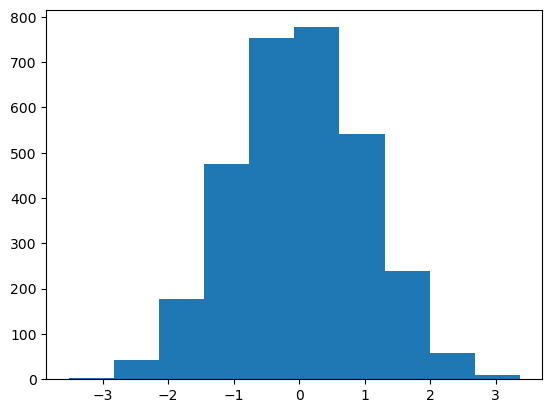

In [45]:
plt.hist(embloc.weight.detach().cpu().numpy().flatten())

(array([  8.,  73., 295., 677., 806., 699., 373., 124.,  20.,   5.]),
 array([-3.26694107, -2.56109834, -1.85525572, -1.14941311, -0.44357038,
         0.26227236,  0.96811485,  1.67395782,  2.37980032,  3.08564281,
         3.79148602]),
 <BarContainer object of 10 artists>)

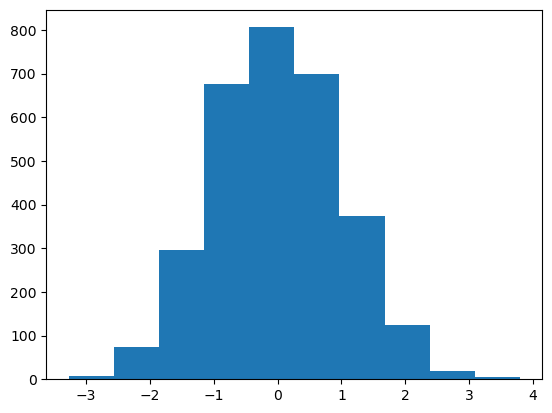

In [47]:
plt.hist(emb_loc.detach().cpu().numpy().flatten())

In [36]:

emb_loc = torch.nn.Parameter(torch.randn(385, loc_embedding_dim), requires_grad=True)
x_loc = torch.nn.functional.one_hot(x_loc.to(torch.int64), num_classes=385).to(torch.float32)
print(x_loc.shape)
x_loc = torch.matmul(x_loc, emb_loc) # (batch, 8)
print(x_loc.shape)
x_loc

torch.Size([4, 385])
torch.Size([4, 8])


tensor([[ 0.0721, -0.1595,  0.6637, -2.0277,  0.6559, -0.0755,  0.0092, -0.4313],
        [-0.4379,  0.5890, -1.4799,  0.4321, -0.6035,  0.1873, -0.2229, -1.2178],
        [-1.0952,  0.2522,  0.7116,  1.6800,  0.1006, -0.1104,  0.1069, -0.5041],
        [ 1.0467, -1.7580,  0.0799, -0.0468,  0.5403, -0.0442,  0.2990,  2.4629]],
       grad_fn=<MmBackward0>)

In [240]:
emb_loc[9]

tensor([ 1.6764,  1.1512, -0.1297, -1.5535, -0.3968,  0.0293,  1.1587,  0.7259],
       grad_fn=<SelectBackward0>)

In [241]:
class GaussianFourierProjection(nn.Module):
    """Gaussian Fourier embeddings for noise levels."""

    def __init__(
        self, embedding_size: int = 256, scale: float = 1.0, set_W_to_weight=True, log=True, flip_sin_to_cos=False
    ):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(embedding_size) * scale, requires_grad=False)
        self.log = log
        self.flip_sin_to_cos = flip_sin_to_cos

        if set_W_to_weight:
            # to delete later
            del self.weight
            self.W = nn.Parameter(torch.randn(embedding_size) * scale, requires_grad=False)
            self.weight = self.W
            del self.W

    def forward(self, t):
        if self.log:
            x = torch.log(x)

        x_proj = t[:, None] * self.weight[None, :] * 2 * np.pi

        if self.flip_sin_to_cos:
            out = torch.cat([torch.cos(x_proj), torch.sin(x_proj)], dim=-1)
        else:
            out = torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)
        return out

In [248]:
t = torch.tensor([1, 2, 3, 4], dtype=torch.long)
t

tensor([1, 2, 3, 4])

In [251]:
time_embed_dim = 64
time_proj = GaussianFourierProjection(time_embed_dim // 2, set_W_to_weight=False, log=False)
time_proj(t).shape

torch.Size([4, 64])

In [260]:
import math
def get_timestep_embedding(
    timesteps: torch.Tensor,
    embedding_dim: int,
    flip_sin_to_cos: bool = False, # [sin, cos] -> [cos, sin]
    downscale_freq_shift: float = 1, # Controls the delta between frequencies between dimensions    
    scale: float = 1, # Scaling factor applied to the embeddings.
    max_period: int = 10000, # Controls the maximum frequency of the embeddings
) -> torch.Tensor:
    """         
    Returns
        torch.Tensor: an [N x embedding_dim] Tensor of positional embeddings.
    """
    assert len(timesteps.shape) == 1, "Timesteps should be a 1d-array"

    half_dim = embedding_dim // 2
    exponent = -math.log(max_period) * torch.arange(
        start=0, end=half_dim, dtype=torch.float32, device=timesteps.device
    )
    exponent = exponent / (half_dim - downscale_freq_shift)

    emb = torch.exp(exponent)
    emb = timesteps[:, None].float() * emb[None, :]

    # scale embeddings
    emb = scale * emb

    # concat sine and cosine embeddings
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)

    # flip sine and cosine embeddings
    if flip_sin_to_cos:
        emb = torch.cat([emb[:, half_dim:], emb[:, :half_dim]], dim=-1)

    # zero pad
    if embedding_dim % 2 == 1:
        emb = torch.nn.functional.pad(emb, (0, 1, 0, 0))
    return emb

In [261]:
class Timesteps(nn.Module):
    def __init__(self, num_channels: int, flip_sin_to_cos: bool, downscale_freq_shift: float, scale: int = 1):
        super().__init__()
        self.num_channels = num_channels
        self.flip_sin_to_cos = flip_sin_to_cos
        self.downscale_freq_shift = downscale_freq_shift
        self.scale = scale

    def forward(self, timesteps: torch.Tensor) -> torch.Tensor:
        t_emb = get_timestep_embedding(
            timesteps,
            self.num_channels,
            flip_sin_to_cos=self.flip_sin_to_cos,
            downscale_freq_shift=self.downscale_freq_shift,
            scale=self.scale,
        )
        return t_emb

In [263]:
time_embed_dim = 64
pos_time_proj = Timesteps(
    16, flip_sin_to_cos=False, downscale_freq_shift=0.0
)
pos_time_proj(t).shape

torch.Size([4, 16])

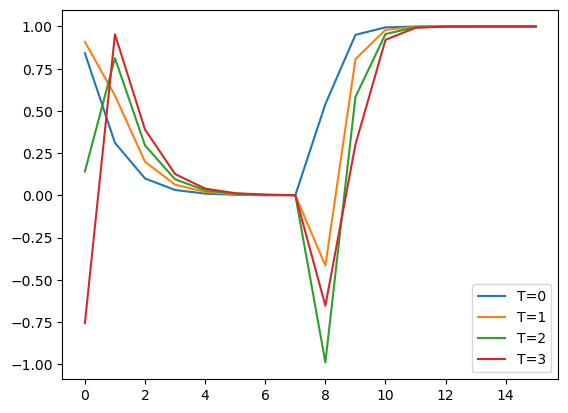

In [266]:
for i, embed in enumerate(pos_time_proj(t)):
    plt.plot(embed, label=f"T={i}")
plt.legend()
plt.show()

In [ ]:
class TimestepEmbedding(nn.Module):
    def __init__(
        self,
        in_channels: int,
        time_embed_dim: int,
        act_fn: str = "silu",
        out_dim: int = None,
        post_act_fn: Optional[str] = None,
        cond_proj_dim=None,
        sample_proj_bias=True,
    ):
        super().__init__()
        self.linear_1 = nn.Linear(in_channels, time_embed_dim, sample_proj_bias)
        if out_dim is not None:
            time_embed_dim_out = out_dim
        else:
            time_embed_dim_out = time_embed_dim
        self.linear_2 = nn.Linear(time_embed_dim, time_embed_dim_out, sample_proj_bias)
        if cond_proj_dim is not None:
            self.cond_proj = nn.Linear(cond_proj_dim, in_channels, bias=False)
        else:
            self.cond_proj = None

        self.act = get_activation(act_fn)

        if post_act_fn is None:
            self.post_act = None
        else:
            self.post_act = get_activation(post_act_fn)

    def forward(self, sample, condition=None):
        if condition is not None:
            sample = sample + self.cond_proj(condition)
        sample = self.linear_1(sample)

        if self.act is not None:
            sample = self.act(sample)

        sample = self.linear_2(sample)

        if self.post_act is not None:
            sample = self.post_act(sample)
        return sample


# Actual Training

Helpful links on training troubleshooting:
- [underfitting](https://stats.stackexchange.com/questions/352036/what-should-i-do-when-my-neural-network-doesnt-learn)
- [Unit testing ML](https://thenerdstation.medium.com/how-to-unit-test-machine-learning-code-57cf6fd81765)